/tmp/ipykernel_885/987621825.py:57: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_885/987621825.py:57: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_885/987621825.py:57: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_885/987621825.py:57: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_885/987621825.py:57: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_885/987621825.py:57: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path

[WARN] 'Total CSMA Energy' missing in /home/hiba/omnetpp-6.0.1/samples/florasatNVArchOC/simulations/CSMASansRetransmissionUnconfirmed/results/florasat_scalars_only.csv — not added


/tmp/ipykernel_885/987621825.py:57: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


[WARN] 'Total CSMA Energy' missing in /home/hiba/omnetpp-6.0.1/samples/florasatNVArchOC/simulations/CSMASansRetransmissionConfirmed/results/florasat_scalars_only.csv — not added

PDR (Confirmed)

--- Pure ALOHA – Confirmed ---
   N    value
  20 0.829004
  50 0.651671
 100 0.489669
 200 0.320167
 400 0.185627
 600 0.129109
 800 0.099274
1000 0.069370

--- Slotted ALOHA – Confirmed ---
   N    value
  20 0.831843
  50 0.661505
 100 0.501063
 200 0.335821
 400 0.203233
 600 0.144911
 800 0.110120
1000 0.082460

--- CSMA – Confirmed ---
   N    value
  20 0.838203
  50 0.652326
 100 0.488485
 200 0.326227
 400 0.187796
 600 0.126609
 800 0.090799
1000 0.069053

PDR (Unconfirmed)

--- Pure ALOHA – Unconfirmed ---
   N    value
  20 0.977818
  50 0.908021
 100 0.833616
 200 0.706539
 400 0.497973
 600 0.379956
 800 0.268362
1000 0.181818

--- Slotted ALOHA – Unconfirmed ---
   N    value
  20 0.886044
  50 0.837298
 100 0.775809
 200 0.670638
 400 0.502486
 600 0.391520
 800 0.288943
1000 0

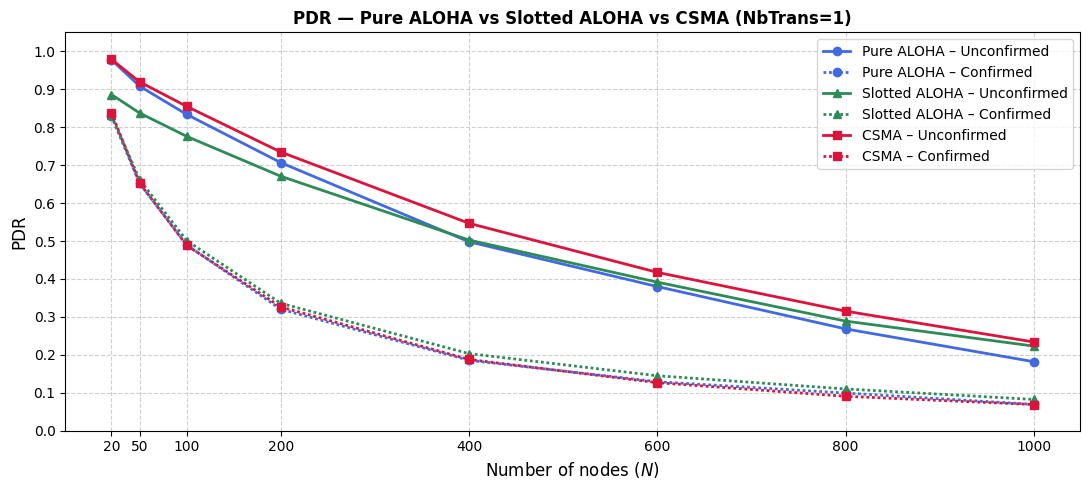

[OK] pdr_3protocols.pdf saved


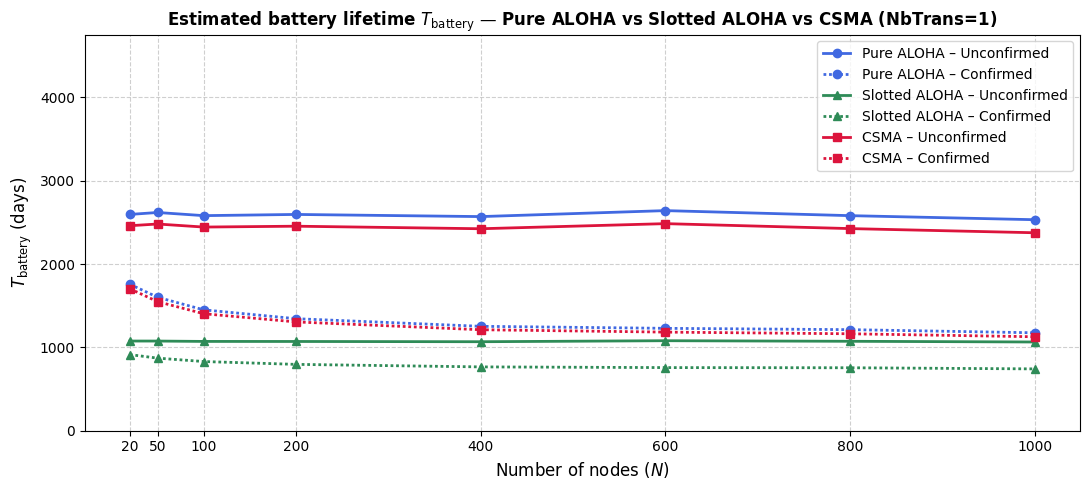

[OK] battery1.png saved


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

BASE = os.getcwd()

# ── File paths ────────────────────────────────────────────────────────────────
PATHS = {
    "aloha": {
        "unconf": os.path.join(BASE, "purealohaSansRetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "conf":   os.path.join(BASE, "purealohaSansRetransmissionConfirmed/results/florasat_scalars_only.csv"),
    },
    "slotted": {
        "unconf": os.path.join(BASE, "SlottedAlohaSansRetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "conf":   os.path.join(BASE, "SlottedAlohaSansRetransmissionConfirmed/results/florasat_scalars_only.csv"),
    },
    "csma": {
        "unconf": os.path.join(BASE, "CSMASansRetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "conf":   os.path.join(BASE, "CSMASansRetransmissionConfirmed/results/florasat_scalars_only.csv"),
    },
}

custom_ticks = [20, 50, 100, 200, 400, 600, 800, 1000]

# ── Curve styling per protocol ───────────────────────────────────────────────
# Naming harmonized with the paper's figure captions and body text:
# "Pure ALOHA", "Slotted ALOHA", "CSMA" (ALOHA fully capitalized, as an acronym)
#
# Pure ALOHA    → royalblue
# Slotted ALOHA → seagreen
# CSMA          → crimson
# Unconfirmed   → solid line   ls="-"
# Confirmed     → dotted line  ls=(0,(1,1))

CURVES = {
    "aloha_unconf":   dict(color="royalblue", marker="o", ls="-",       lw=2, label="Pure ALOHA – Unconfirmed"),
    "aloha_conf":     dict(color="royalblue", marker="o", ls=(0,(1,1)), lw=2, label="Pure ALOHA – Confirmed"),
    "slotted_unconf": dict(color="seagreen",  marker="^", ls="-",       lw=2, label="Slotted ALOHA – Unconfirmed"),
    "slotted_conf":   dict(color="seagreen",  marker="^", ls=(0,(1,1)), lw=2, label="Slotted ALOHA – Confirmed"),
    "csma_unconf":    dict(color="crimson",   marker="s", ls="-",       lw=2, label="CSMA – Unconfirmed"),
    "csma_conf":      dict(color="crimson",   marker="s", ls=(0,(1,1)), lw=2, label="CSMA – Confirmed"),
}

LABELS = {k: v["label"] for k, v in CURVES.items()}

# ── Battery model parameters ─────────────────────────────────────────────────

BATTERY_CAPACITY_MAH = 3400
BATTERY_VOLTAGE_V = 3.3          # matches <supplyVoltage value="3.3"/> in energyConsumer XML
BATTERY_ENERGY_J = BATTERY_CAPACITY_MAH * BATTERY_VOLTAGE_V * 3.6  # mAh -> Joules


SIM_DURATION_S = 900

# ── Helpers ───────────────────────────────────────────────────────────────────
def _load(csv_path):
    df = pd.read_csv(csv_path)
    for col in ["name", "module", "run"]:
        df[col] = df[col].astype(str).str.strip()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    return df


def _N_dict(df):
    itervars = df[df["type"] == "itervar"]
    N_vals = itervars[itervars["attrname"] == "N"][["run", "attrvalue"]].copy()
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")
    return dict(zip(N_vals["run"], N_vals["N"]))


def get_results(csv_path, scalar_name, module_filter=None):
    df = _load(csv_path)
    N_vals = (df[df["type"] == "itervar"]
              .query("attrname == 'N'")[["run", "attrvalue"]]
              .copy())
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")

    mask = df["name"] == scalar_name
    if module_filter:
        mask &= df["module"].str.contains(module_filter, na=False)
    sub = df[mask].copy()
    if sub.empty:
        print(f"[WARN] '{scalar_name}' missing in {csv_path}")
        return pd.DataFrame(columns=["N", "value"])

    per_run = sub.groupby("run")["value"].mean()
    wide = per_run.reset_index().merge(N_vals[["run", "N"]], on="run")
    return wide.groupby("N", as_index=False)["value"].mean().sort_values("N")


def get_energy_per_node(csv_path, with_csma_energy=False):
    df = _load(csv_path)
    N_dict = _N_dict(df)

    mask_e = (df["name"] == "totalEnergyConsumed") & \
             df["module"].str.contains("loRaNodes", na=False)
    sub_e = df[mask_e][["run", "module", "value"]].rename(columns={"value": "energy"})

    if sub_e.empty:
        print(f"[WARN] totalEnergyConsumed missing in {csv_path}")
        return pd.DataFrame(columns=["N", "value"])

    if with_csma_energy:
        mask_c = (df["name"] == "Total CSMA Energy (J)") & \
                 df["module"].str.contains("loRaNodes", na=False)
        sub_c = df[mask_c][["run", "module", "value"]].rename(columns={"value": "csma_energy"})
        if sub_c.empty:
            print(f"[WARN] 'Total CSMA Energy' missing in {csv_path} — not added")
            sub_e["total"] = sub_e["energy"]
            merged = sub_e
        else:
            merged = sub_e.merge(sub_c, on=["run", "module"], how="left")
            merged["csma_energy"] = merged["csma_energy"].fillna(0)
            merged["total"] = merged["energy"] + merged["csma_energy"]
    else:
        sub_e["total"] = sub_e["energy"]
        merged = sub_e

    merged["node_idx"] = merged["module"].str.extract(r"loRaNodes\[(\d+)\]").astype(float)
    merged["N"] = merged["run"].map(N_dict)
    merged = merged.dropna(subset=["N", "node_idx"])
    merged = merged[merged["node_idx"] < merged["N"]]

    mean_per_run = merged.groupby(["run", "N"])["total"].mean().reset_index()
    result = mean_per_run.groupby("N", as_index=False)["total"].mean().sort_values("N")
    return result.rename(columns={"total": "value"})


def get_pdr_confirmed(csv_path):
    ack  = get_results(csv_path, "receivedAckPackets")
    sent = get_results(csv_path, "numSent")
    if ack.empty or sent.empty:
        return ack
    merged = ack.merge(sent, on="N", suffixes=("_ack", "_sent"))
    out = merged[["N"]].copy()
    out["value"] = merged["value_ack"] / merged["value_sent"]
    return out


def get_battery_lifetime(csv_path, sim_duration_s, with_csma_energy=False):
    """
    Estimate battery lifetime T_battery (in days) from the average per-node
    energy consumed during one simulated satellite pass, matching the
    T_battery definition given in the paper's Simulations subsection.

    Assumption: the node repeats the same energy consumption pattern at every
    pass (i.e. this ignores idle-state energy consumption during the periods
    when the satellite is NOT visible, between passes).
    """
    if sim_duration_s is None:
        raise ValueError("SIM_DURATION_S must be set to the satellite pass duration (s).")

    energy_df = get_energy_per_node(csv_path, with_csma_energy=with_csma_energy)
    if energy_df.empty:
        return energy_df

    out = energy_df.copy()
    avg_power_w = out["value"] / sim_duration_s          # average power during the pass (W)
    lifetime_s = BATTERY_ENERGY_J / avg_power_w           # estimated lifetime (s)
    out["value"] = lifetime_s / 86400                     # convert to days
    return out


def print_scenario_tables(data_dict, title, unit=""):
    print(f"\n{'='*80}")
    print(title)
    print(f"{'='*80}")
    for scenario, df in data_dict.items():
        print(f"\n--- {LABELS[scenario]} ---")
        if df is None or df.empty:
            print("No data")
            continue
        display_df = df.copy()
        display_df["value"] = display_df["value"].round(6)
        if unit:
            display_df["value"] = display_df["value"].astype(str) + f" {unit}"
        print(display_df.to_string(index=False))


# ── Load PDR (still useful for reference / other figures) ───────────────────
pdr = {}

pdr["aloha_unconf"] = get_results(PATHS["aloha"]["unconf"], "LoRa_NS_DER", "networkServer")
if pdr["aloha_unconf"].empty:
    pdr["aloha_unconf"] = get_results(PATHS["aloha"]["unconf"], "LoRa_NS_DER")
pdr["aloha_conf"] = get_pdr_confirmed(PATHS["aloha"]["conf"])

pdr["slotted_unconf"] = get_results(PATHS["slotted"]["unconf"], "LoRa_NS_DER", "networkServer")
if pdr["slotted_unconf"].empty:
    pdr["slotted_unconf"] = get_results(PATHS["slotted"]["unconf"], "LoRa_NS_DER")
pdr["slotted_conf"] = get_pdr_confirmed(PATHS["slotted"]["conf"])

pdr["csma_unconf"] = get_results(PATHS["csma"]["unconf"], "LoRa_NS_DER", "networkServer")
if pdr["csma_unconf"].empty:
    pdr["csma_unconf"] = get_results(PATHS["csma"]["unconf"], "LoRa_NS_DER")
pdr["csma_conf"] = get_pdr_confirmed(PATHS["csma"]["conf"])

# ── Load battery lifetime (T_battery) ────────────────────────────────────────
# IMPORTANT: set SIM_DURATION_S above to your actual satellite pass duration
SIM_DURATION_S = 900

t_battery = {
    "aloha_unconf":   get_battery_lifetime(PATHS["aloha"]["unconf"],   SIM_DURATION_S, with_csma_energy=False),
    "aloha_conf":     get_battery_lifetime(PATHS["aloha"]["conf"],     SIM_DURATION_S, with_csma_energy=False),
    "slotted_unconf": get_battery_lifetime(PATHS["slotted"]["unconf"], SIM_DURATION_S, with_csma_energy=False),
    "slotted_conf":   get_battery_lifetime(PATHS["slotted"]["conf"],   SIM_DURATION_S, with_csma_energy=False),
    "csma_unconf":    get_battery_lifetime(PATHS["csma"]["unconf"],    SIM_DURATION_S, with_csma_energy=True),
    "csma_conf":      get_battery_lifetime(PATHS["csma"]["conf"],      SIM_DURATION_S, with_csma_energy=True),
}

# ── Console output ────────────────────────────────────────────────────────────
pdr_confirmed = {k: pdr[k] for k in ["aloha_conf", "slotted_conf", "csma_conf"]}
pdr_unconfirmed = {k: pdr[k] for k in ["aloha_unconf", "slotted_unconf", "csma_unconf"]}

print_scenario_tables(pdr_confirmed, "PDR (Confirmed)")
print_scenario_tables(pdr_unconfirmed, "PDR (Unconfirmed)")
print_scenario_tables(t_battery, "T_battery (Estimated Battery Lifetime)", unit="days")

# ── Figure 2 in the paper: PDR, NbTrans=1 (fig:pdr_aloha_csma) ──────────────
# Saved filename matches \includegraphics{pdr_3protocols.pdf} in the .tex
fig1, ax1 = plt.subplots(figsize=(11, 5))
for key, df in pdr.items():
    if df is not None and not df.empty:
        s = CURVES[key]
        ax1.plot(df["N"], df["value"],
                 marker=s["marker"], color=s["color"], linewidth=s["lw"],
                 linestyle=s["ls"], label=s["label"])

ax1.set_xlabel("Number of nodes ($N$)", fontsize=12)
ax1.set_ylabel("PDR", fontsize=12)
ax1.set_title("PDR — Pure ALOHA vs Slotted ALOHA vs CSMA (NbTrans=1)",
              fontsize=12, fontweight="bold")
ax1.set_ylim(0, 1.05)
ax1.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax1.set_xticks(custom_ticks)
ax1.legend(fontsize=10)
ax1.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("pdr_3protocols.pdf")
plt.show()
print("[OK] pdr_3protocols.pdf saved")

# ── Figure "battery1" in the paper: T_battery, NbTrans=1 (fig:battery1) ─────
# Saved filename matches \includegraphics{battery1.png} in the .tex
fig2, ax2 = plt.subplots(figsize=(11, 5))
for key, df in t_battery.items():
    if df is not None and not df.empty:
        s = CURVES[key]
        ax2.plot(df["N"], df["value"],
                 marker=s["marker"], color=s["color"], linewidth=s["lw"],
                 linestyle=s["ls"], label=s["label"])
max_lifetime = max(df["value"].max() for df in t_battery.values() if df is not None and not df.empty)
ax2.set_ylim(0, max_lifetime * 1.8)
ax2.set_xlabel("Number of nodes ($N$)", fontsize=12)
ax2.set_ylabel(r"$T_{\mathrm{battery}}$ (days)", fontsize=12)
ax2.set_title(r"Estimated battery lifetime $T_{\mathrm{battery}}$ — "
              "Pure ALOHA vs Slotted ALOHA vs CSMA (NbTrans=1)",
              fontsize=12, fontweight="bold")

ax2.set_xticks(custom_ticks)
ax2.legend(fontsize=10)
ax2.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("battery1.png", dpi=300)
plt.show()
print("[OK] battery1.png saved")

/tmp/ipykernel_885/4148097057.py:85: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_885/4148097057.py:85: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_885/4148097057.py:85: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_885/4148097057.py:85: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_885/4148097057.py:85: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_885/4148097057.py:85: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cs

[WARN] 'Total CSMA Energy' absent dans /home/hiba/omnetpp-6.0.1/samples/florasatNVArchOC/simulations/CSMASansRetransmissionConfirmed/results/florasat_scalars_only.csv — non ajouté


/tmp/ipykernel_885/4148097057.py:85: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_885/4148097057.py:85: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_885/4148097057.py:85: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_885/4148097057.py:85: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_885/4148097057.py:85: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_885/4148097057.py:85: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cs

[WARN] 'Total CSMA Energy' absent dans /home/hiba/omnetpp-6.0.1/samples/florasatNVArchOC/simulations/CSMAAvec7RetransmissionConfirmed/results/florasat_scalars_only.csv — non ajouté

  PDR (ACK / SentPackets) — Confirmed

--- Pure ALOHA – NbTrans=1 ---
   N    value
  20 0.829004
  50 0.651671
 100 0.489669
 200 0.320167
 400 0.185627
 600 0.129109
 800 0.099274
1000 0.069370

--- Pure ALOHA – NbTrans=3 ---
   N    value
  20 0.968615
  50 0.788174
 100 0.536519
 200 0.304957
 400 0.117350
 600 0.057795
 800 0.032586
1000 0.016493

--- Pure ALOHA – NbTrans=8 ---
   N    value
  20 0.995130
  50 0.889539
 100 0.516570
 200 0.181192
 400 0.039752
 600 0.012356
 800 0.008454
1000 0.006193

--- Slotted ALOHA – NbTrans=1 ---
   N    value
  20 0.754870
  50 0.606464
 100 0.456522
 200 0.306747
 400 0.186591
 600 0.132784
 800 0.099677
1000 0.074755

--- Slotted ALOHA – NbTrans=3 ---
   N    value
  20 0.876082
  50 0.791658
 100 0.602454
 200 0.372382
 400 0.190716
 600 0.121145
 800 0.07506

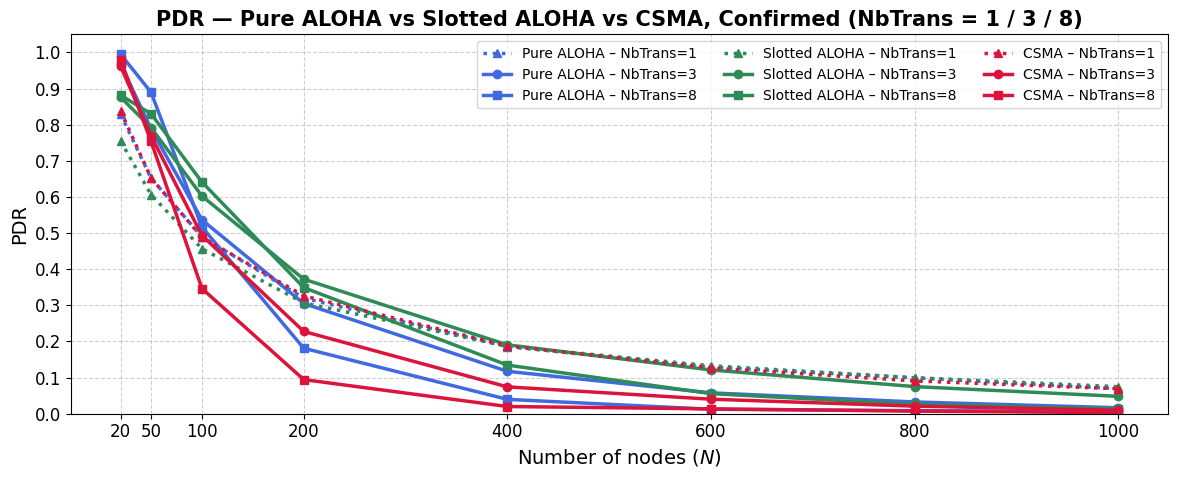

[OK] pdr_all_protocols_conf.pdf sauvegardé


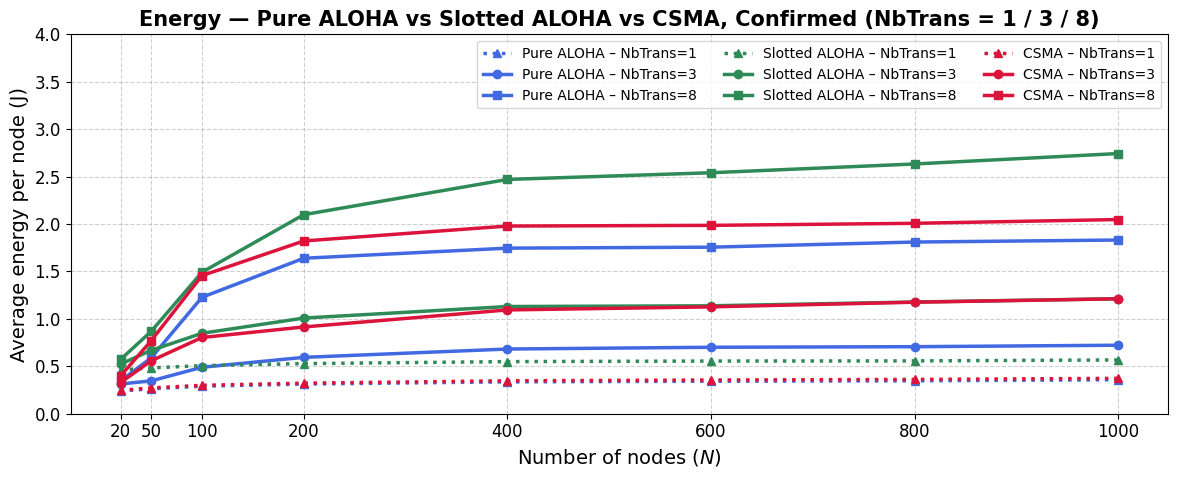

[OK] energy_all_protocols_conf.pdf sauvegardé (figure non référencée dans le .tex)


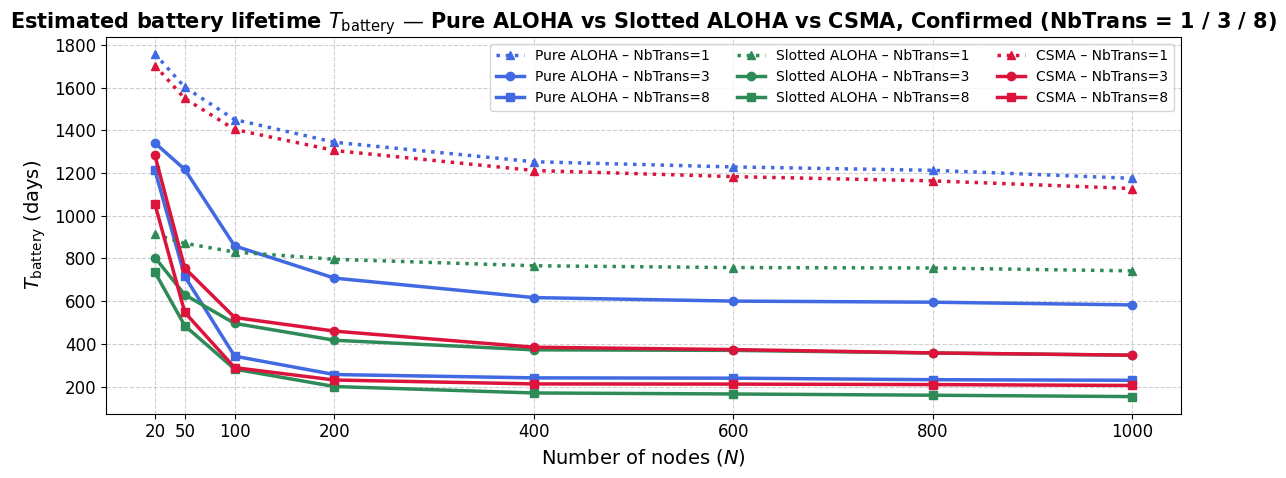

[OK] battery2.pdf sauvegardé


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 10,
})

BASE = os.getcwd()

# ── Chemins ────────────────────────────────────────────────────────────────────
PATHS = {
    "pure_aloha": {
        "0retx": os.path.join(BASE, "purealohaSansRetransmissionConfirmed/results/florasat_scalars_only.csv"),
        "2retx": os.path.join(BASE, "pureAlohaAvec2RetransmissionConfirmed/results/florasat_scalars_only.csv"),
        "7retx": os.path.join(BASE, "pureAlohaAvec7RetransmissionConfirmed/results/florasat_scalars_only.csv"),
    },
    "slotted_aloha": {
        "0retx": os.path.join(BASE, "SlottedAlohaSansRetransmissionConfirmed/results/florasat_scalars_only.csv"),
        "2retx": os.path.join(BASE, "SlottedAlohaAvec2RetransmissionConfirmed/results/florasat_scalars_only.csv"),
        "7retx": os.path.join(BASE, "SlottedAlohaAvec7RetransmissionConfirmed/results/florasat_scalars_only.csv"),
    },
    "csma": {
        "0retx": os.path.join(BASE, "CSMASansRetransmissionConfirmed/results/florasat_scalars_only.csv"),
        "2retx": os.path.join(BASE, "CSMAAvec2RetransmissionConfirmed/results/florasat_scalars_only.csv"),
        "7retx": os.path.join(BASE, "CSMAAvec7RetransmissionConfirmed/results/florasat_scalars_only.csv"),
    },
}

custom_ticks = [20, 50, 100, 200, 400, 600, 800, 1000]

# ── Encodage visuel ────────────────────────────────────────────────────────────
COLORS = {
    "pure_aloha":    "royalblue",
    "slotted_aloha": "seagreen",
    "csma":          "crimson",
}

# Naming harmonized with the paper's body text and figure captions:
# "Pure ALOHA", "Slotted ALOHA", "CSMA" (ALOHA fully capitalized, as an acronym)
PROTO_LABELS = {
    "pure_aloha":    "Pure ALOHA",
    "slotted_aloha": "Slotted ALOHA",
    "csma":          "CSMA",
}

MARKERS    = {"0retx": "^", "2retx": "o", "7retx": "s"}
LINESTYLES = {"0retx": ":",  "2retx": "-",  "7retx": "-"}
NBTRANS_LABELS = {
    "0retx": "NbTrans=1",
    "2retx": "NbTrans=3",
    "7retx": "NbTrans=8",
}

# Génération automatique du dictionnaire de style (9 courbes)
CURVES = {}
for proto in PATHS:
    for retx in ["0retx", "2retx", "7retx"]:
        key = f"{proto}_{retx}"
        CURVES[key] = dict(
            color=COLORS[proto],
            marker=MARKERS[retx],
            ls=LINESTYLES[retx],
            lw=2.5,
            ms=6,
            label=f"{PROTO_LABELS[proto]} – {NBTRANS_LABELS[retx]}",
        )


BATTERY_CAPACITY_MAH = 3400
BATTERY_VOLTAGE_V = 3.3          # matches <supplyVoltage value="3.3"/> in energyConsumer XML
BATTERY_ENERGY_J = BATTERY_CAPACITY_MAH * BATTERY_VOLTAGE_V * 3.6  # mAh -> Joules

# Duration of one satellite pass in seconds (simulation period).
SIM_DURATION_S = 900


# ── Helpers ────────────────────────────────────────────────────────────────────
def _load(csv_path):
    df = pd.read_csv(csv_path)
    for col in ["name", "module", "run"]:
        df[col] = df[col].astype(str).str.strip()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    return df


def _N_dict(df):
    itervars = df[df["type"] == "itervar"]
    N_vals = itervars[itervars["attrname"] == "N"][["run", "attrvalue"]].copy()
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")
    return dict(zip(N_vals["run"], N_vals["N"]))


def get_results(csv_path, scalar_name, module_filter=None):
    df = _load(csv_path)
    N_vals = (df[df["type"] == "itervar"]
              .query("attrname == 'N'")[["run", "attrvalue"]].copy())
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")

    mask = df["name"] == scalar_name
    if module_filter:
        mask &= df["module"].str.contains(module_filter, na=False)
    sub = df[mask].copy()
    if sub.empty:
        print(f"[WARN] '{scalar_name}' absent dans {csv_path}")
        return pd.DataFrame(columns=["N", "value"])

    per_run = sub.groupby("run")["value"].mean()
    wide = per_run.reset_index().merge(N_vals[["run", "N"]], on="run")
    return wide.groupby("N", as_index=False)["value"].mean().sort_values("N")


def get_pdr_confirmed(csv_path):
    """PDR = receivedAckPackets / sentPackets"""
    ack  = get_results(csv_path, "receivedAckPackets")
    sent = get_results(csv_path, "sentPackets")
    if ack.empty or sent.empty:
        return ack
    merged = ack.merge(sent, on="N", suffixes=("_ack", "_sent"))
    out = merged[["N"]].copy()
    out["value"] = merged["value_ack"] / merged["value_sent"]
    return out


def get_energy_per_node(csv_path, with_csma_energy=False):
    """Energie moyenne par noeud actif (node_idx < N)."""
    df = _load(csv_path)
    N_dict_map = _N_dict(df)

    mask_e = (df["name"] == "totalEnergyConsumed") & \
              df["module"].str.contains("loRaNodes", na=False)
    sub_e = df[mask_e][["run", "module", "value"]].rename(columns={"value": "energy"})

    # Fallback si le filtre module ne remonte rien
    if sub_e.empty:
        mask_e2 = df["name"] == "totalEnergyConsumed"
        sub_e = df[mask_e2][["run", "module", "value"]].rename(columns={"value": "energy"})
        if sub_e.empty:
            print(f"[WARN] totalEnergyConsumed absent dans {csv_path}")
            return pd.DataFrame(columns=["N", "value"])

    if with_csma_energy:
        mask_c = (df["name"] == "Total CSMA Energy (J)") & \
                  df["module"].str.contains("loRaNodes", na=False)
        sub_c = df[mask_c][["run", "module", "value"]].rename(columns={"value": "csma_energy"})
        if sub_c.empty:
            print(f"[WARN] 'Total CSMA Energy' absent dans {csv_path} — non ajouté")
            sub_e["total"] = sub_e["energy"]
            merged = sub_e
        else:
            merged = sub_e.merge(sub_c, on=["run", "module"], how="left")
            merged["csma_energy"] = merged["csma_energy"].fillna(0)
            merged["total"] = merged["energy"] + merged["csma_energy"]
    else:
        sub_e["total"] = sub_e["energy"]
        merged = sub_e

    merged["node_idx"] = merged["module"].str.extract(r"loRaNodes\[(\d+)\]").astype(float)
    merged["N"] = merged["run"].map(N_dict_map)
    merged = merged.dropna(subset=["N", "node_idx"])
    merged = merged[merged["node_idx"] < merged["N"]]

    mean_per_run = merged.groupby(["run", "N"])["total"].mean().reset_index()
    result = mean_per_run.groupby("N", as_index=False)["total"].mean().sort_values("N")
    return result.rename(columns={"total": "value"})


def get_battery_lifetime_from_energy(energy_df, sim_duration_s):
    """
    Estimate battery lifetime T_battery (in days) from a per-node energy
    dataframe (output of get_energy_per_node), matching the T_battery
    definition given in the paper's Simulations subsection. Assumes the
    same energy pattern repeats at every satellite pass.
    """
    if energy_df is None or energy_df.empty:
        return pd.DataFrame(columns=["N", "value"])

    out = energy_df.copy()
    avg_power_w = out["value"] / sim_duration_s          # average power during the pass (W)
    lifetime_s = BATTERY_ENERGY_J / avg_power_w           # estimated lifetime (s)
    out["value"] = lifetime_s / 86400                     # convert to days
    return out


# ── Chargement des données ─────────────────────────────────────────────────────
pdr        = {}
energy     = {}
t_battery  = {}

for proto, paths in PATHS.items():
    use_csma_energy = (proto == "csma")
    for retx, path in paths.items():
        key = f"{proto}_{retx}"
        pdr[key]       = get_pdr_confirmed(path)
        energy[key]    = get_energy_per_node(path, with_csma_energy=use_csma_energy)
        t_battery[key] = get_battery_lifetime_from_energy(energy[key], SIM_DURATION_S)


# ── Affichage tabulaire ────────────────────────────────────────────────────────
def print_scenario_tables(data_dict, title, unit=""):
    print(f"\n{'='*70}")
    print(f"  {title}")
    print(f"{'='*70}")
    for key, df in data_dict.items():
        label = CURVES[key]["label"]
        print(f"\n--- {label} ---")
        if df is None or df.empty:
            print("  Aucune donnée")
            continue
        display = df.copy()
        display["value"] = display["value"].round(6)
        if unit:
            display["value"] = display["value"].astype(str) + f" {unit}"
        print(display.to_string(index=False))

print_scenario_tables(pdr,       "PDR (ACK / SentPackets) — Confirmed")
print_scenario_tables(energy,    "Énergie moyenne par nœud — Confirmed", unit="J")
print_scenario_tables(t_battery, "T_battery (Estimated Battery Lifetime) — Confirmed", unit="days")


# ── Figure 4 dans le papier : PDR, Confirmed, NbTrans ∈ {1,3,8} (fig:pdr_nbtrans) ──
# Nom de fichier conforme à \includegraphics{pdr_all_protocols_conf.pdf}
fig1, ax1 = plt.subplots(figsize=(12, 5))

for key, df in pdr.items():
    if df is not None and not df.empty:
        s = CURVES[key]
        ax1.plot(df["N"], df["value"],
                 marker=s["marker"], color=s["color"],
                 linewidth=s["lw"], markersize=s["ms"],
                 linestyle=s["ls"], label=s["label"])

ax1.set_xlabel("Number of nodes ($N$)")
ax1.set_ylabel("PDR")
ax1.set_title(
    "PDR — Pure ALOHA vs Slotted ALOHA vs CSMA, Confirmed (NbTrans = 1 / 3 / 8)",
    fontweight="bold"
)
ax1.set_ylim(0, 1.05)
ax1.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax1.set_xticks(custom_ticks)
ax1.legend(ncol=3)
ax1.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("pdr_all_protocols_conf.pdf", bbox_inches="tight")
plt.show()
print("[OK] pdr_all_protocols_conf.pdf sauvegardé")


# ── Figure additionnelle (non référencée dans le .tex) : Énergie moyenne ────
# NOTE: aucune \includegraphics{energy_all_protocols_conf...} n'existe
# actuellement dans le papier. Conservée ici pour analyse interne ; à ajouter
# au .tex si vous souhaitez l'inclure comme figure supplémentaire.
fig2, ax2 = plt.subplots(figsize=(12, 5))

for key, df in energy.items():
    if df is not None and not df.empty:
        s = CURVES[key]
        ax2.plot(df["N"], df["value"],
                 marker=s["marker"], color=s["color"],
                 linewidth=s["lw"], markersize=s["ms"],
                 linestyle=s["ls"], label=s["label"])

ax2.set_xlabel("Number of nodes ($N$)")
ax2.set_ylabel("Average energy per node (J)")
ax2.set_title(
    "Energy — Pure ALOHA vs Slotted ALOHA vs CSMA, Confirmed (NbTrans = 1 / 3 / 8)",
    fontweight="bold"
)
ax2.set_ylim(bottom=0, top=4)
ax2.set_xticks(custom_ticks)
ax2.legend(ncol=3)
ax2.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("energy_all_protocols_conf.pdf", bbox_inches="tight")
plt.show()
print("[OK] energy_all_protocols_conf.pdf sauvegardé (figure non référencée dans le .tex)")


# ── Figure "battery2" dans le papier : T_battery, Confirmed, NbTrans ∈ {1,3,8} ──
# Nom de fichier conforme à \includegraphics{battery2.pdf} (label fig:battery2)
fig3, ax3 = plt.subplots(figsize=(12, 5))

for key, df in t_battery.items():
    if df is not None and not df.empty:
        s = CURVES[key]
        ax3.plot(df["N"], df["value"],
                 marker=s["marker"], color=s["color"],
                 linewidth=s["lw"], markersize=s["ms"],
                 linestyle=s["ls"], label=s["label"])

ax3.set_xlabel("Number of nodes ($N$)")
ax3.set_ylabel(r"$T_{\mathrm{battery}}$ (days)")
ax3.set_title(
    r"Estimated battery lifetime $T_{\mathrm{battery}}$ — "
    "Pure ALOHA vs Slotted ALOHA vs CSMA, Confirmed (NbTrans = 1 / 3 / 8)",
    fontweight="bold"
)
ax3.set_xticks(custom_ticks)
ax3.legend(ncol=3)
ax3.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("battery2.pdf", bbox_inches="tight")
plt.show()
print("[OK] battery2.pdf sauvegardé")

/tmp/ipykernel_905/737799600.py:52: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_905/737799600.py:52: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_905/737799600.py:52: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_905/737799600.py:52: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_905/737799600.py:52: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_905/737799600.py:52: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path

[WARN] 'Total CSMA Energy' absent dans /home/hiba/omnetpp-6.0.1/samples/florasatNVArchOC/simulations/CSMASansRetransmissionUnconfirmed/results/florasat_scalars_only.csv — non ajouté


/tmp/ipykernel_905/737799600.py:52: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


[WARN] 'Total CSMA Energy' absent dans /home/hiba/omnetpp-6.0.1/samples/florasatNVArchOC/simulations/CSMASansRetransmissionConfirmed/results/florasat_scalars_only.csv — non ajouté

PDR (Confirmed)

--- Pure Aloha – Confirmed ---
   N    value
  20 0.829004
  50 0.651671
 100 0.489669
 200 0.320167
 400 0.185627
 600 0.138767
 800 0.099274
1000 0.069370

--- Slotted Aloha – Confirmed ---
   N    value
  20 0.836017
  50 0.669128
 100 0.509331
 200 0.343641
 400 0.203233
 600 0.144911
 800 0.110120
1000 0.082460

--- CSMA – Confirmed ---
   N    value
  20 0.838203
  50 0.652326
 100 0.488485
 200 0.326227
 400 0.187796
 600 0.131057
 800 0.090799
1000 0.069053

PDR (Unconfirmed)

--- Pure Aloha – Unconfirmed ---
   N    value
  20 0.977818
  50 0.908021
 100 0.833616
 200 0.706539
 400 0.497973
 600 0.379956
 800 0.268362
1000 0.181818

--- Slotted Aloha – Unconfirmed ---
   N    value
  20 0.888799
  50 0.843002
 100 0.782414
 200 0.680086
 400 0.513636
 600 0.392284
 800 0.299435
1000

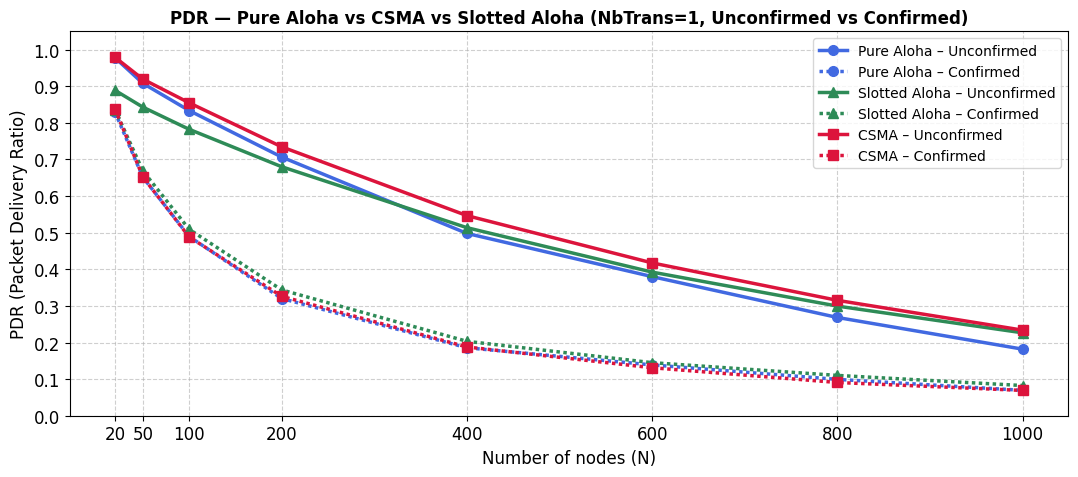

[OK] pdr_3protocols.png sauvegardé


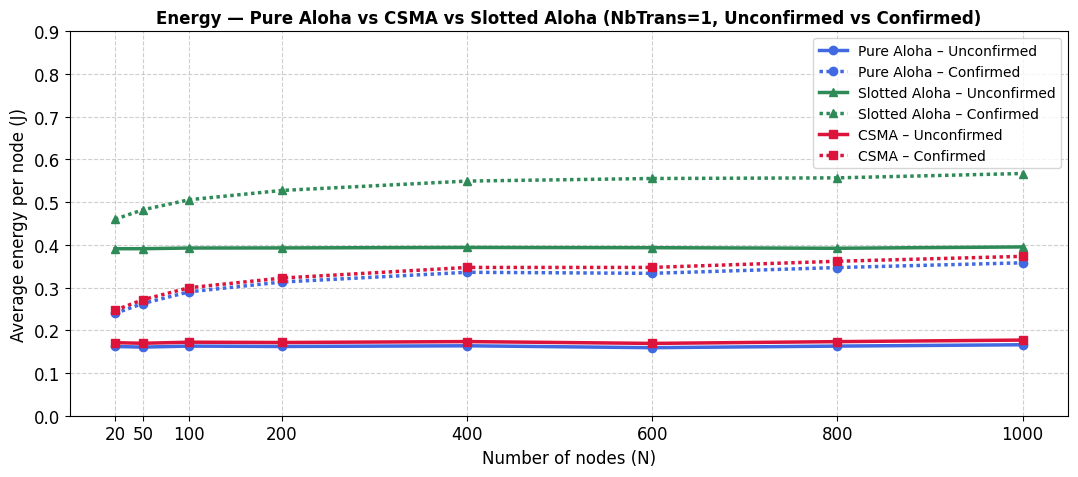

[OK] energy_3protocols.png sauvegardé


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import os
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
})
BASE = os.getcwd()

# ── Chemins ───────────────────────────────────────────────────────────────────
PATHS = {
    "aloha": {
        "unconf": os.path.join(BASE, "purealohaSansRetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "conf":   os.path.join(BASE, "purealohaSansRetransmissionConfirmed/results/florasat_scalars_only.csv"),
    },
    "slotted": {
        "unconf": os.path.join(BASE, "SlottedAlohaSansRetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "conf":   os.path.join(BASE, "SlottedAlohaSansRetransmissionConfirmed/results/florasat_scalars_only.csv"),
    },
    "csma": {
        "unconf": os.path.join(BASE, "CSMASansRetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "conf":   os.path.join(BASE, "CSMASansRetransmissionConfirmed/results/florasat_scalars_only.csv"),
    },
}

custom_ticks = [20, 50, 100, 200, 400, 600, 800, 1000]

# ── Couleurs par protocole ────────────────────────────────────────────────────
# Pure Aloha  → royalblue
# Slotted     → seagreen
# CSMA        → crimson
# Unconfirmed → trait plein   ls="-"
# Confirmed   → trait pointillé ls=(0,(1,1))

CURVES = {
    "aloha_unconf":   dict(color="royalblue", marker="o", ls="-",       lw=2.5, ms=7, label="Pure Aloha – Unconfirmed"),
    "aloha_conf":     dict(color="royalblue", marker="o", ls=(0,(1,1)), lw=2.5, ms=7, label="Pure Aloha – Confirmed"),
    "slotted_unconf": dict(color="seagreen",  marker="^", ls="-",       lw=2.5, ms=7, label="Slotted Aloha – Unconfirmed"),
    "slotted_conf":   dict(color="seagreen",  marker="^", ls=(0,(1,1)), lw=2.5, ms=7, label="Slotted Aloha – Confirmed"),
    "csma_unconf":    dict(color="crimson",   marker="s", ls="-",       lw=2.5, ms=7, label="CSMA – Unconfirmed"),
    "csma_conf":      dict(color="crimson",   marker="s", ls=(0,(1,1)), lw=2.5, ms=7, label="CSMA – Confirmed"),
}

LABELS = {k: v["label"] for k, v in CURVES.items()}

# ── Helpers ───────────────────────────────────────────────────────────────────
def _load(csv_path):
    df = pd.read_csv(csv_path)
    for col in ["name", "module", "run"]:
        df[col] = df[col].astype(str).str.strip()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    return df


def _N_dict(df):
    itervars = df[df["type"] == "itervar"]
    N_vals = itervars[itervars["attrname"] == "N"][["run", "attrvalue"]].copy()
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")
    return dict(zip(N_vals["run"], N_vals["N"]))


def get_results(csv_path, scalar_name, module_filter=None):
    df = _load(csv_path)
    N_vals = (df[df["type"] == "itervar"]
              .query("attrname == 'N'")[["run", "attrvalue"]]
              .copy())
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")

    mask = df["name"] == scalar_name
    if module_filter:
        mask &= df["module"].str.contains(module_filter, na=False)
    sub = df[mask].copy()
    if sub.empty:
        print(f"[WARN] '{scalar_name}' absent dans {csv_path}")
        return pd.DataFrame(columns=["N", "value"])

    per_run = sub.groupby("run")["value"].mean()
    wide = per_run.reset_index().merge(N_vals[["run", "N"]], on="run")
    return wide.groupby("N", as_index=False)["value"].mean().sort_values("N")


def get_energy_per_node(csv_path, with_csma_energy=False):
    df = _load(csv_path)
    N_dict = _N_dict(df)

    mask_e = (df["name"] == "totalEnergyConsumed") & \
             df["module"].str.contains("loRaNodes", na=False)
    sub_e = df[mask_e][["run", "module", "value"]].rename(columns={"value": "energy"})

    if sub_e.empty:
        print(f"[WARN] totalEnergyConsumed absent dans {csv_path}")
        return pd.DataFrame(columns=["N", "value"])

    if with_csma_energy:
        mask_c = (df["name"] == "Total CSMA Energy (J)") & \
                 df["module"].str.contains("loRaNodes", na=False)
        sub_c = df[mask_c][["run", "module", "value"]].rename(columns={"value": "csma_energy"})
        if sub_c.empty:
            print(f"[WARN] 'Total CSMA Energy' absent dans {csv_path} — non ajouté")
            sub_e["total"] = sub_e["energy"]
            merged = sub_e
        else:
            merged = sub_e.merge(sub_c, on=["run", "module"], how="left")
            merged["csma_energy"] = merged["csma_energy"].fillna(0)
            merged["total"] = merged["energy"] + merged["csma_energy"]
    else:
        sub_e["total"] = sub_e["energy"]
        merged = sub_e

    merged["node_idx"] = merged["module"].str.extract(r"loRaNodes\[(\d+)\]").astype(float)
    merged["N"] = merged["run"].map(N_dict)
    merged = merged.dropna(subset=["N", "node_idx"])
    merged = merged[merged["node_idx"] < merged["N"]]

    mean_per_run = merged.groupby(["run", "N"])["total"].mean().reset_index()
    result = mean_per_run.groupby("N", as_index=False)["total"].mean().sort_values("N")
    return result.rename(columns={"total": "value"})


def get_pdr_confirmed(csv_path):
    ack  = get_results(csv_path, "receivedAckPackets")
    sent = get_results(csv_path, "numSent")
    if ack.empty or sent.empty:
        return ack
    merged = ack.merge(sent, on="N", suffixes=("_ack", "_sent"))
    out = merged[["N"]].copy()
    out["value"] = merged["value_ack"] / merged["value_sent"]
    return out


# ── Chargement PDR ────────────────────────────────────────────────────────────
pdr = {}

# Pure Aloha
pdr["aloha_unconf"] = get_results(PATHS["aloha"]["unconf"], "LoRa_NS_DER", "networkServer")
if pdr["aloha_unconf"].empty:
    pdr["aloha_unconf"] = get_results(PATHS["aloha"]["unconf"], "LoRa_NS_DER")
pdr["aloha_conf"] = get_pdr_confirmed(PATHS["aloha"]["conf"])

# Slotted Aloha
pdr["slotted_unconf"] = get_results(PATHS["slotted"]["unconf"], "LoRa_NS_DER", "networkServer")
if pdr["slotted_unconf"].empty:
    pdr["slotted_unconf"] = get_results(PATHS["slotted"]["unconf"], "LoRa_NS_DER")
pdr["slotted_conf"] = get_pdr_confirmed(PATHS["slotted"]["conf"])

# CSMA
pdr["csma_unconf"] = get_results(PATHS["csma"]["unconf"], "LoRa_NS_DER", "networkServer")
if pdr["csma_unconf"].empty:
    pdr["csma_unconf"] = get_results(PATHS["csma"]["unconf"], "LoRa_NS_DER")
pdr["csma_conf"] = get_pdr_confirmed(PATHS["csma"]["conf"])

# ── Chargement Énergie ────────────────────────────────────────────────────────
energy = {
    "aloha_unconf":   get_energy_per_node(PATHS["aloha"]["unconf"],   with_csma_energy=False),
    "aloha_conf":     get_energy_per_node(PATHS["aloha"]["conf"],     with_csma_energy=False),
    "slotted_unconf": get_energy_per_node(PATHS["slotted"]["unconf"], with_csma_energy=False),
    "slotted_conf":   get_energy_per_node(PATHS["slotted"]["conf"],   with_csma_energy=False),
    "csma_unconf":    get_energy_per_node(PATHS["csma"]["unconf"],    with_csma_energy=True),
    "csma_conf":      get_energy_per_node(PATHS["csma"]["conf"],      with_csma_energy=True),
}

# ── Affichage console ─────────────────────────────────────────────────────────
def print_scenario_tables(data_dict, title, unit=""):
    print(f"\n{'='*80}")
    print(title)
    print(f"{'='*80}")
    for scenario, df in data_dict.items():
        print(f"\n--- {LABELS[scenario]} ---")
        if df is None or df.empty:
            print("Aucune donnée")
            continue
        display_df = df.copy()
        display_df["value"] = display_df["value"].round(6)
        if unit:
            display_df["value"] = display_df["value"].astype(str) + f" {unit}"
        print(display_df.to_string(index=False))

# ── Affichage des PDR Confirmed ───────────────────────────────────────────────
pdr_confirmed = {
    "aloha_conf": pdr["aloha_conf"],
    "slotted_conf": pdr["slotted_conf"],
    "csma_conf": pdr["csma_conf"],
}

print_scenario_tables(pdr_confirmed, "PDR (Confirmed)")
pdr_unconfirmed = {
    "aloha_unconf": pdr["aloha_unconf"],
    "slotted_unconf": pdr["slotted_unconf"],
    "csma_unconf": pdr["csma_unconf"],
}

print_scenario_tables(pdr_unconfirmed, "PDR (Unconfirmed)")
print_scenario_tables(pdr_confirmed, "PDR (Confirmed)")


print_scenario_tables(energy, "Énergie moyenne par nœud", unit="J")

# ── Figure 1 : PDR ────────────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(11, 5))
for key, df in pdr.items():
    if df is not None and not df.empty:
        s = CURVES[key]
        ax1.plot(df["N"], df["value"],
         marker=s["marker"], color=s["color"], linewidth=s["lw"],
         markersize=s["ms"], linestyle=s["ls"], label=s["label"])
ax1.set_xlabel("Number of nodes (N)", fontsize=12)
ax1.set_ylabel("PDR (Packet Delivery Ratio)", fontsize=12)
ax1.set_title("PDR — Pure Aloha vs CSMA vs Slotted Aloha (NbTrans=1, Unconfirmed vs Confirmed)",
              fontsize=12, fontweight="bold")

ax1.set_ylim(0, 1.05)
ax1.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax1.set_xticks(custom_ticks)
ax1.legend(fontsize=10)
ax1.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("pdr_3protocols.pdf", bbox_inches="tight")
plt.show()
print("[OK] pdr_3protocols.png sauvegardé")

# ── Figure 2 : Énergie ────────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(11, 5))
for key, df in energy.items():
    if df is not None and not df.empty:
        s = CURVES[key]
        ax2.plot(df["N"], df["value"],
                 marker=s["marker"], color=s["color"], linewidth=s["lw"],
                 linestyle=s["ls"], label=s["label"])
ax2.set_xlabel("Number of nodes (N)", fontsize=12)
ax2.set_ylabel("Average energy per node (J)", fontsize=12)
ax2.set_title("Energy — Pure Aloha vs CSMA vs Slotted Aloha (NbTrans=1, Unconfirmed vs Confirmed)",
              fontsize=12, fontweight="bold")


ax2.set_ylim(0, 0.9)
ax2.set_xticks(custom_ticks)
ax2.legend(fontsize=10)
ax2.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("energy_3protocols.pdf", bbox_inches="tight")
plt.show()
print("[OK] energy_3protocols.png sauvegardé")

/tmp/ipykernel_905/1362371060.py:77: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_905/1362371060.py:77: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_905/1362371060.py:77: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_905/1362371060.py:77: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_905/1362371060.py:77: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_905/1362371060.py:77: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cs

[WARN] 'Total CSMA Energy' absent dans /home/hiba/omnetpp-6.0.1/samples/florasatNVArchOC/simulations/CSMASansRetransmissionConfirmed/results/florasat_scalars_only.csv — non ajouté


/tmp/ipykernel_905/1362371060.py:77: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_905/1362371060.py:77: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_905/1362371060.py:77: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_905/1362371060.py:77: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_905/1362371060.py:77: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_905/1362371060.py:77: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cs


  PDR (ACK / SentPackets) — Confirmed

--- Pure Aloha – NbTrans=1 ---
   N    value
  20 0.829004
  50 0.651671
 100 0.489669
 200 0.320167
 400 0.185627
 600 0.138767
 800 0.099274
1000 0.069370

--- Pure Aloha – NbTrans=3 ---
   N    value
  20 0.960163
  50 0.788174
 100 0.536519
 200 0.304957
 400 0.117350
 600 0.057795
 800 0.032586
1000 0.016493

--- Pure Aloha – NbTrans=8 ---
   N    value
  20 0.982114
  50 0.889539
 100 0.516570
 200 0.181192
 400 0.039752
 600 0.012356
 800 0.008454
1000 0.006193

--- Slotted Aloha – NbTrans=1 ---
   N    value
  20 0.758658
  50 0.613453
 100 0.464055
 200 0.313890
 400 0.186591
 600 0.132784
 800 0.099677
1000 0.074755

--- Slotted Aloha – NbTrans=3 ---
   N    value
  20 0.876082
  50 0.791658
 100 0.602454
 200 0.372382
 400 0.190716
 600 0.121145
 800 0.075061
1000 0.048147

--- Slotted Aloha – NbTrans=8 ---
   N    value
  20 0.881494
  50 0.830094
 100 0.641089
 200 0.349061
 400 0.134600
 600 0.055617
 800 0.025827
1000 0.013621

---

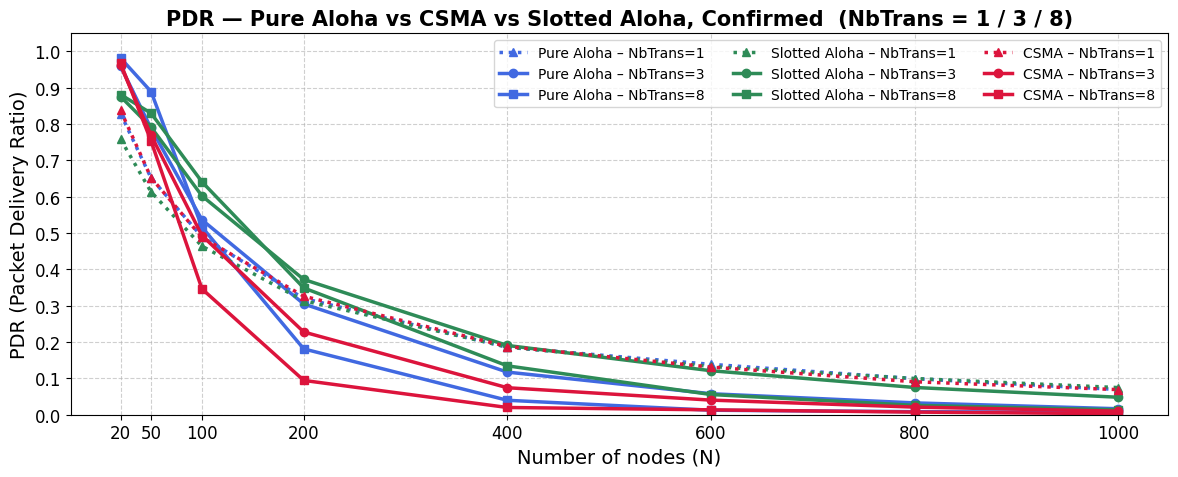

[OK] pdr_all_protocols_conf.pdf sauvegardé


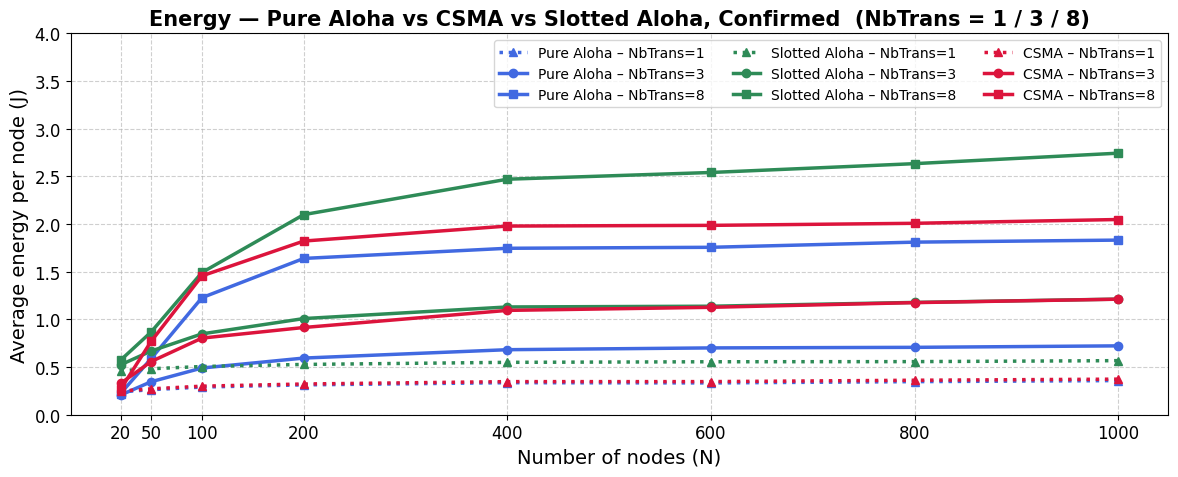

[OK] energy_all_protocols_conf.pdf sauvegardé


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import os

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 10,
})

BASE = os.getcwd()

# ── Chemins ────────────────────────────────────────────────────────────────────
PATHS = {
    "pure_aloha": {
        "0retx": os.path.join(BASE, "purealohaSansRetransmissionConfirmed/results/florasat_scalars_only.csv"),
        "2retx": os.path.join(BASE, "pureAlohaAvec2RetransmissionConfirmed/results/florasat_scalars_only.csv"),
        "7retx": os.path.join(BASE, "pureAlohaAvec7RetransmissionConfirmed/results/florasat_scalars_only.csv"),
    },
    "slotted_aloha": {
        "0retx": os.path.join(BASE, "SlottedAlohaSansRetransmissionConfirmed/results/florasat_scalars_only.csv"),
        "2retx": os.path.join(BASE, "SlottedAlohaAvec2RetransmissionConfirmed/results/florasat_scalars_only.csv"),
        "7retx": os.path.join(BASE, "SlottedAlohaAvec7RetransmissionConfirmed/results/florasat_scalars_only.csv"),
    },
    "csma": {
        "0retx": os.path.join(BASE, "CSMASansRetransmissionConfirmed/results/florasat_scalars_only.csv"),
        "2retx": os.path.join(BASE, "CSMAAvec2RetransmissionConfirmed/results/florasat_scalars_only.csv"),
        "7retx": os.path.join(BASE, "CSMAAvec7RetransmissionConfirmed/results/florasat_scalars_only.csv"),
    },
}

custom_ticks = [20, 50, 100, 200, 400, 600, 800, 1000]

# ── Encodage visuel ────────────────────────────────────────────────────────────
COLORS = {
    "pure_aloha":    "royalblue",
    "slotted_aloha": "seagreen",
    "csma":          "crimson",
}

PROTO_LABELS = {
    "pure_aloha":    "Pure Aloha",
    "slotted_aloha": "Slotted Aloha",
    "csma":          "CSMA",
}

MARKERS    = {"0retx": "^", "2retx": "o", "7retx": "s"}
LINESTYLES = {"0retx": ":",  "2retx": "-",  "7retx": "-"}
NBTRANS_LABELS = {
    "0retx": "NbTrans=1",
    "2retx": "NbTrans=3",
    "7retx": "NbTrans=8",
}

# Génération automatique du dictionnaire de style (9 courbes)
# Ordre : par protocole puis par NbTrans → dans la légende ncol=3,
# chaque colonne regroupe un protocole
CURVES = {}
for proto in PATHS:
    for retx in ["0retx", "2retx", "7retx"]:
        key = f"{proto}_{retx}"
        CURVES[key] = dict(
            color=COLORS[proto],
            marker=MARKERS[retx],
            ls=LINESTYLES[retx],
            lw=2.5,
            ms=6,
            label=f"{PROTO_LABELS[proto]} – {NBTRANS_LABELS[retx]}",
        )


# ── Helpers ────────────────────────────────────────────────────────────────────
def _load(csv_path):
    df = pd.read_csv(csv_path)
    for col in ["name", "module", "run"]:
        df[col] = df[col].astype(str).str.strip()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    return df


def _N_dict(df):
    itervars = df[df["type"] == "itervar"]
    N_vals = itervars[itervars["attrname"] == "N"][["run", "attrvalue"]].copy()
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")
    return dict(zip(N_vals["run"], N_vals["N"]))


def get_results(csv_path, scalar_name, module_filter=None):
    df = _load(csv_path)
    N_vals = (df[df["type"] == "itervar"]
              .query("attrname == 'N'")[["run", "attrvalue"]].copy())
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")

    mask = df["name"] == scalar_name
    if module_filter:
        mask &= df["module"].str.contains(module_filter, na=False)
    sub = df[mask].copy()
    if sub.empty:
        print(f"[WARN] '{scalar_name}' absent dans {csv_path}")
        return pd.DataFrame(columns=["N", "value"])

    per_run = sub.groupby("run")["value"].mean()
    wide = per_run.reset_index().merge(N_vals[["run", "N"]], on="run")
    return wide.groupby("N", as_index=False)["value"].mean().sort_values("N")


def get_pdr_confirmed(csv_path):
    """PDR = receivedAckPackets / sentPackets"""
    ack  = get_results(csv_path, "receivedAckPackets")
    sent = get_results(csv_path, "sentPackets")
    if ack.empty or sent.empty:
        return ack
    merged = ack.merge(sent, on="N", suffixes=("_ack", "_sent"))
    out = merged[["N"]].copy()
    out["value"] = merged["value_ack"] / merged["value_sent"]
    return out


def get_energy_per_node(csv_path, with_csma_energy=False):
    """Energie moyenne par noeud actif (node_idx < N)."""
    df = _load(csv_path)
    N_dict_map = _N_dict(df)

    mask_e = (df["name"] == "totalEnergyConsumed") & \
              df["module"].str.contains("loRaNodes", na=False)
    sub_e = df[mask_e][["run", "module", "value"]].rename(columns={"value": "energy"})

    # Fallback si le filtre module ne remonte rien
    if sub_e.empty:
        mask_e2 = df["name"] == "totalEnergyConsumed"
        sub_e = df[mask_e2][["run", "module", "value"]].rename(columns={"value": "energy"})
        if sub_e.empty:
            print(f"[WARN] totalEnergyConsumed absent dans {csv_path}")
            return pd.DataFrame(columns=["N", "value"])

    if with_csma_energy:
        mask_c = (df["name"] == "Total CSMA Energy (J)") & \
                  df["module"].str.contains("loRaNodes", na=False)
        sub_c = df[mask_c][["run", "module", "value"]].rename(columns={"value": "csma_energy"})
        if sub_c.empty:
            print(f"[WARN] 'Total CSMA Energy' absent dans {csv_path} — non ajouté")
            sub_e["total"] = sub_e["energy"]
            merged = sub_e
        else:
            merged = sub_e.merge(sub_c, on=["run", "module"], how="left")
            merged["csma_energy"] = merged["csma_energy"].fillna(0)
            merged["total"] = merged["energy"] + merged["csma_energy"]
    else:
        sub_e["total"] = sub_e["energy"]
        merged = sub_e

    merged["node_idx"] = merged["module"].str.extract(r"loRaNodes\[(\d+)\]").astype(float)
    merged["N"] = merged["run"].map(N_dict_map)
    merged = merged.dropna(subset=["N", "node_idx"])
    merged = merged[merged["node_idx"] < merged["N"]]

    mean_per_run = merged.groupby(["run", "N"])["total"].mean().reset_index()
    result = mean_per_run.groupby("N", as_index=False)["total"].mean().sort_values("N")
    return result.rename(columns={"total": "value"})


# ── Chargement des données ─────────────────────────────────────────────────────
pdr    = {}
energy = {}

for proto, paths in PATHS.items():
    use_csma_energy = (proto == "csma")
    for retx, path in paths.items():
        key = f"{proto}_{retx}"
        pdr[key]    = get_pdr_confirmed(path)
        energy[key] = get_energy_per_node(path, with_csma_energy=use_csma_energy)


# ── Affichage tabulaire ────────────────────────────────────────────────────────
def print_scenario_tables(data_dict, title, unit=""):
    print(f"\n{'='*70}")
    print(f"  {title}")
    print(f"{'='*70}")
    for key, df in data_dict.items():
        label = CURVES[key]["label"]
        print(f"\n--- {label} ---")
        if df is None or df.empty:
            print("  Aucune donnée")
            continue
        display = df.copy()
        display["value"] = display["value"].round(6)
        if unit:
            display["value"] = display["value"].astype(str) + f" {unit}"
        print(display.to_string(index=False))

print_scenario_tables(pdr,    "PDR (ACK / SentPackets) — Confirmed")
print_scenario_tables(energy, "Énergie moyenne par nœud — Confirmed", unit="J")


# ── Figure 1 : PDR ────────────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(12, 5))

for key, df in pdr.items():
    if df is not None and not df.empty:
        s = CURVES[key]
        ax1.plot(df["N"], df["value"],
                 marker=s["marker"], color=s["color"],
                 linewidth=s["lw"], markersize=s["ms"],
                 linestyle=s["ls"], label=s["label"])

ax1.set_xlabel("Number of nodes (N)")
ax1.set_ylabel("PDR (Packet Delivery Ratio)")
ax1.set_title(
    "PDR — Pure Aloha vs CSMA vs Slotted Aloha, Confirmed  (NbTrans = 1 / 3 / 8)",
    fontweight="bold"
)
ax1.set_ylim(0, 1.05)
ax1.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax1.set_xticks(custom_ticks)
# ncol=3 → 1 colonne par protocole dans la légende
ax1.legend(ncol=3)
ax1.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("pdr_all_protocols_conf.pdf", bbox_inches="tight")
plt.show()
print("[OK] pdr_all_protocols_conf.pdf sauvegardé")


# ── Figure 2 : Énergie ────────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(12, 5))

for key, df in energy.items():
    if df is not None and not df.empty:
        s = CURVES[key]
        ax2.plot(df["N"], df["value"],
                 marker=s["marker"], color=s["color"],
                 linewidth=s["lw"], markersize=s["ms"],
                 linestyle=s["ls"], label=s["label"])

ax2.set_xlabel("Number of nodes (N)")
ax2.set_ylabel("Average energy per node (J)")
ax2.set_title(
    "Energy — Pure Aloha vs CSMA vs Slotted Aloha, Confirmed  (NbTrans = 1 / 3 / 8)",
    fontweight="bold"
)
ax2.set_ylim(bottom=0, top=4)
ax2.set_xticks(custom_ticks)
ax2.legend(ncol=3)
ax2.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("energy_all_protocols_conf.pdf", bbox_inches="tight")
plt.show()
print("[OK] energy_all_protocols_conf.pdf sauvegardé")

/tmp/ipykernel_885/2242438354.py:84: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_885/2242438354.py:84: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_885/2242438354.py:84: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_885/2242438354.py:84: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_885/2242438354.py:84: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_885/2242438354.py:84: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cs

[WARN] 'Total CSMA Energy' absent dans /home/hiba/omnetpp-6.0.1/samples/florasatNVArchOC/simulations/CSMASansRetransmissionUnconfirmed/results/florasat_scalars_only.csv — non ajouté


/tmp/ipykernel_885/2242438354.py:84: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_885/2242438354.py:84: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_885/2242438354.py:84: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_885/2242438354.py:84: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)



  PDR (LoRa_NS_DER) — Unconfirmed

--- Pure ALOHA – NbTrans=1 ---
   N    value
  20 0.977818
  50 0.908021
 100 0.833616
 200 0.706539
 400 0.497973
 600 0.379956
 800 0.268362
1000 0.181818

--- Pure ALOHA – NbTrans=3 ---
   N    value
  20 0.995770
  50 0.975432
 100 0.923969
 200 0.783842
 400 0.483433
 600 0.279600
 800 0.163007
1000 0.100095

--- Pure ALOHA – NbTrans=8 ---
   N    value
  20 0.997856
  50 0.986988
 100 0.909981
 200 0.591265
 400 0.161491
 600 0.047649
 800 0.020178
1000 0.010770

--- Slotted ALOHA – NbTrans=1 ---
   N    value
  20 0.886044
  50 0.837298
 100 0.775809
 200 0.670638
 400 0.502486
 600 0.391520
 800 0.288943
1000 0.222997

--- Slotted ALOHA – NbTrans=3 ---
   N    value
  20 0.885601
  50 0.834115
 100 0.756436
 200 0.601214
 400 0.353046
 600 0.229626
 800 0.131154
1000 0.068419

--- Slotted ALOHA – NbTrans=8 ---
   N    value
  20 0.879629
  50 0.802900
 100 0.643519
 200 0.357774
 400 0.109001
 600 0.053414
 800 0.030670
1000 0.018055

--- CSM

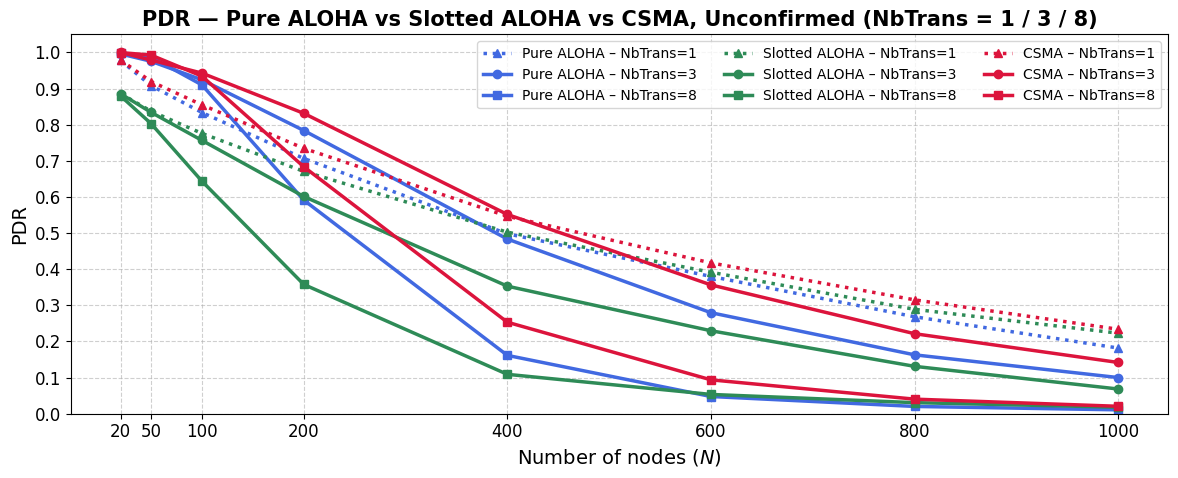

[OK] pdr_all_protocols_unc.pdf sauvegardé


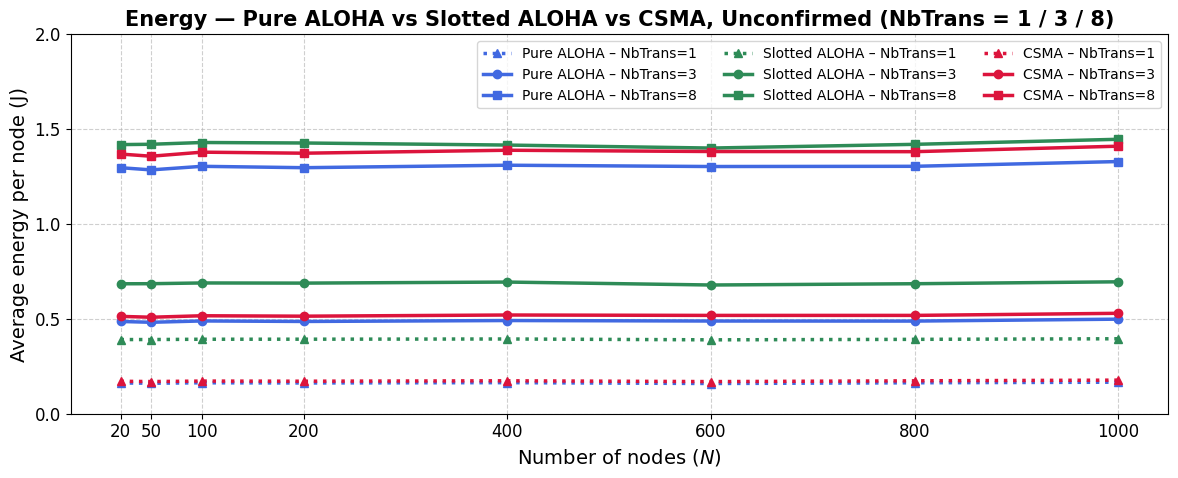

[OK] energy_all_protocols_unc.pdf sauvegardé (figure non référencée dans le .tex)


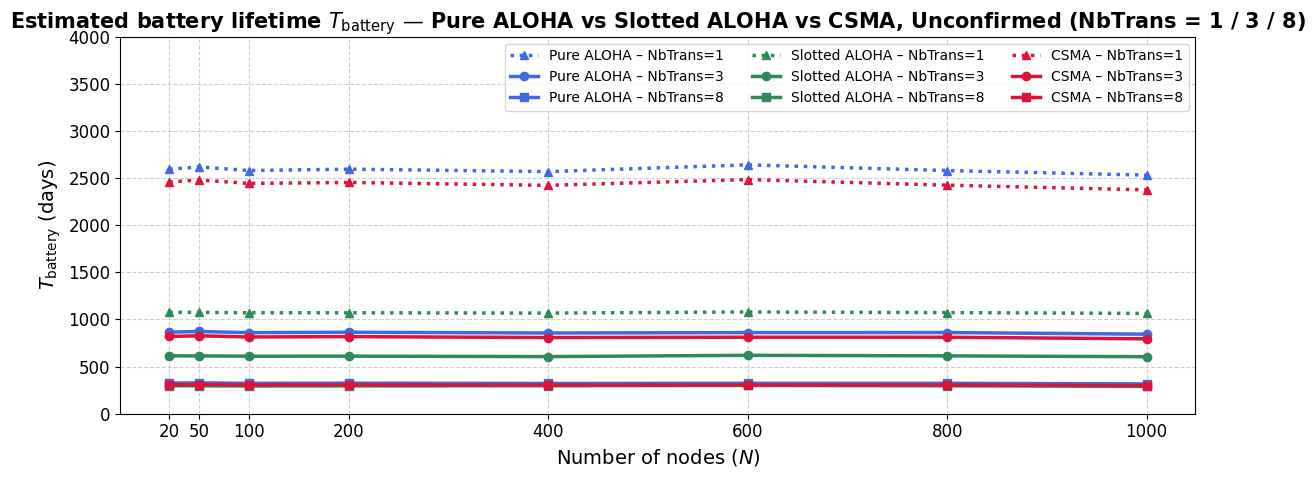

[OK] battery_unc.pdf sauvegardé


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import os

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 10,
})

BASE = os.getcwd()

# ── Chemins ────────────────────────────────────────────────────────────────────
PATHS = {
    "pure_aloha": {
        "0retx": os.path.join(BASE, "purealohaSansRetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "2retx": os.path.join(BASE, "pureAlohaAvec2RetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "7retx": os.path.join(BASE, "pureAlohaAvec7RetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
    },
    "slotted_aloha": {
        "0retx": os.path.join(BASE, "SlottedAlohaSansRetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "2retx": os.path.join(BASE, "SlottedAlohaAvec2RetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "7retx": os.path.join(BASE, "SlottedAlohaAvec7RetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
    },
    "csma": {
        "0retx": os.path.join(BASE, "CSMASansRetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "2retx": os.path.join(BASE, "CSMAAvec2RetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "7retx": os.path.join(BASE, "CSMAAvec7RetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
    },
}

custom_ticks = [20, 50, 100, 200, 400, 600, 800, 1000]

# ── Encodage visuel ────────────────────────────────────────────────────────────
COLORS = {
    "pure_aloha":    "royalblue",
    "slotted_aloha": "seagreen",
    "csma":          "crimson",
}

# Naming harmonized with the paper's body text and figure captions:
# "Pure ALOHA", "Slotted ALOHA", "CSMA" (ALOHA fully capitalized, as an acronym)
PROTO_LABELS = {
    "pure_aloha":    "Pure ALOHA",
    "slotted_aloha": "Slotted ALOHA",
    "csma":          "CSMA",
}

MARKERS    = {"0retx": "^", "2retx": "o", "7retx": "s"}
LINESTYLES = {"0retx": ":",  "2retx": "-",  "7retx": "-"}
NBTRANS_LABELS = {
    "0retx": "NbTrans=1",
    "2retx": "NbTrans=3",
    "7retx": "NbTrans=8",
}

# Génération du dictionnaire de style (9 courbes)
CURVES = {}
for proto in PATHS:
    for retx in ["0retx", "2retx", "7retx"]:
        key = f"{proto}_{retx}"
        CURVES[key] = dict(
            color=COLORS[proto],
            marker=MARKERS[retx],
            ls=LINESTYLES[retx],
            lw=2.5,
            ms=6,
            label=f"{PROTO_LABELS[proto]} – {NBTRANS_LABELS[retx]}",
        )

# ── Battery model parameters (identical to the other T_battery scripts) ─────
BATTERY_CAPACITY_MAH = 3400
BATTERY_VOLTAGE_V = 3.3          # matches <supplyVoltage value="3.3"/> in energyConsumer XML
BATTERY_ENERGY_J = BATTERY_CAPACITY_MAH * BATTERY_VOLTAGE_V * 3.6  # mAh -> Joules

SIM_DURATION_S = 900  # duration of one satellite pass (s)


# ── Helpers ────────────────────────────────────────────────────────────────────
def _load(csv_path):
    df = pd.read_csv(csv_path)
    for col in ["name", "module", "run"]:
        df[col] = df[col].astype(str).str.strip()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    return df


def _N_dict(df):
    itervars = df[df["type"] == "itervar"]
    N_vals = itervars[itervars["attrname"] == "N"][["run", "attrvalue"]].copy()
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")
    return dict(zip(N_vals["run"], N_vals["N"]))


def get_results(csv_path, scalar_name, module_filter=None):
    df = _load(csv_path)
    N_vals = (df[df["type"] == "itervar"]
              .query("attrname == 'N'")[["run", "attrvalue"]].copy())
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")

    mask = df["name"] == scalar_name
    if module_filter:
        mask &= df["module"].str.contains(module_filter, na=False)
    sub = df[mask].copy()
    if sub.empty:
        print(f"[WARN] '{scalar_name}' absent dans {csv_path}")
        return pd.DataFrame(columns=["N", "value"])

    per_run = sub.groupby("run")["value"].mean()
    wide = per_run.reset_index().merge(N_vals[["run", "N"]], on="run")
    return wide.groupby("N", as_index=False)["value"].mean().sort_values("N")


def get_pdr_unconfirmed(csv_path):
    """PDR unconfirmed : LoRa_NS_DER depuis le networkServer (fallback sans filtre)."""
    der = get_results(csv_path, "LoRa_NS_DER", module_filter="networkServer")
    if der.empty:
        der = get_results(csv_path, "LoRa_NS_DER")
    return der


def get_energy_per_node(csv_path, with_csma_energy=False):
    """Energie moyenne par nœud actif (node_idx < N)."""
    df = _load(csv_path)
    N_dict_map = _N_dict(df)

    mask_e = (df["name"] == "totalEnergyConsumed") & \
              df["module"].str.contains("loRaNodes", na=False)
    sub_e = df[mask_e][["run", "module", "value"]].rename(columns={"value": "energy"})

    if sub_e.empty:
        mask_e2 = df["name"] == "totalEnergyConsumed"
        sub_e = df[mask_e2][["run", "module", "value"]].rename(columns={"value": "energy"})
        if sub_e.empty:
            print(f"[WARN] totalEnergyConsumed absent dans {csv_path}")
            return pd.DataFrame(columns=["N", "value"])

    if with_csma_energy:
        mask_c = (df["name"] == "Total CSMA Energy (J)") & \
                  df["module"].str.contains("loRaNodes", na=False)
        sub_c = df[mask_c][["run", "module", "value"]].rename(columns={"value": "csma_energy"})
        if sub_c.empty:
            print(f"[WARN] 'Total CSMA Energy' absent dans {csv_path} — non ajouté")
            sub_e["total"] = sub_e["energy"]
            merged = sub_e
        else:
            merged = sub_e.merge(sub_c, on=["run", "module"], how="left")
            merged["csma_energy"] = merged["csma_energy"].fillna(0)
            merged["total"] = merged["energy"] + merged["csma_energy"]
    else:
        sub_e["total"] = sub_e["energy"]
        merged = sub_e

    merged["node_idx"] = merged["module"].str.extract(r"loRaNodes\[(\d+)\]").astype(float)
    merged["N"] = merged["run"].map(N_dict_map)
    merged = merged.dropna(subset=["N", "node_idx"])
    merged = merged[merged["node_idx"] < merged["N"]]

    mean_per_run = merged.groupby(["run", "N"])["total"].mean().reset_index()
    result = mean_per_run.groupby("N", as_index=False)["total"].mean().sort_values("N")
    return result.rename(columns={"total": "value"})


def get_battery_lifetime(energy_df, sim_duration_s):
    """
    Convert average per-node energy (J) into estimated battery lifetime
    T_battery (in days), matching the T_battery definition given in the
    paper's Simulations subsection. Assumes the same energy pattern repeats
    at every satellite pass.
    """
    if energy_df is None or energy_df.empty:
        return pd.DataFrame(columns=["N", "value"])

    out = energy_df.copy()
    avg_power_w = out["value"] / sim_duration_s   # average power during the pass (W)
    lifetime_s = BATTERY_ENERGY_J / avg_power_w    # estimated lifetime (s)
    out["value"] = lifetime_s / 86400              # convert to days
    return out


# ── Chargement des données ─────────────────────────────────────────────────────
pdr       = {}
energy    = {}
t_battery = {}

for proto, paths in PATHS.items():
    use_csma_energy = (proto == "csma")
    for retx, path in paths.items():
        key = f"{proto}_{retx}"
        pdr[key]       = get_pdr_unconfirmed(path)
        energy[key]    = get_energy_per_node(path, with_csma_energy=use_csma_energy)
        t_battery[key] = get_battery_lifetime(energy[key], SIM_DURATION_S)


# ── Affichage tabulaire ────────────────────────────────────────────────────────
def print_scenario_tables(data_dict, title, unit=""):
    print(f"\n{'='*70}")
    print(f"  {title}")
    print(f"{'='*70}")
    for key, df in data_dict.items():
        label = CURVES[key]["label"]
        print(f"\n--- {label} ---")
        if df is None or df.empty:
            print("  Aucune donnée")
            continue
        display = df.copy()
        display["value"] = display["value"].round(6)
        if unit:
            display["value"] = display["value"].astype(str) + f" {unit}"
        print(display.to_string(index=False))

print_scenario_tables(pdr,       "PDR (LoRa_NS_DER) — Unconfirmed")
print_scenario_tables(energy,    "Énergie moyenne par nœud — Unconfirmed", unit="J")
print_scenario_tables(t_battery, "T_battery (Estimated Battery Lifetime) — Unconfirmed", unit="days")


# ── Figure 3 dans le papier : PDR, Unconfirmed, NbTrans ∈ {1,3,8} ───────────
# (fig:pdr_nbtrans_unc). Nom de fichier conforme à
# \includegraphics{pdr_all_protocols_unc.pdf} — inchangé.
fig1, ax1 = plt.subplots(figsize=(12, 5))

for key, df in pdr.items():
    if df is not None and not df.empty:
        s = CURVES[key]
        ax1.plot(df["N"], df["value"],
                 marker=s["marker"], color=s["color"],
                 linewidth=s["lw"], markersize=s["ms"],
                 linestyle=s["ls"], label=s["label"])

ax1.set_xlabel("Number of nodes ($N$)")
ax1.set_ylabel("PDR")
ax1.set_title(
    "PDR — Pure ALOHA vs Slotted ALOHA vs CSMA, Unconfirmed (NbTrans = 1 / 3 / 8)",
    fontweight="bold"
)
ax1.set_ylim(0, 1.05)
ax1.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax1.set_xticks(custom_ticks)
ax1.legend(ncol=3)   # 1 colonne par protocole
ax1.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("pdr_all_protocols_unc.pdf", bbox_inches="tight")
plt.show()
print("[OK] pdr_all_protocols_unc.pdf sauvegardé")


# ── Figure additionnelle (non référencée dans le .tex) : Énergie moyenne ────
# NOTE: conservée pour analyse interne (énergie brute, pas T_battery).
fig2, ax2 = plt.subplots(figsize=(12, 5))

for key, df in energy.items():
    if df is not None and not df.empty:
        s = CURVES[key]
        ax2.plot(df["N"], df["value"],
                 marker=s["marker"], color=s["color"],
                 linewidth=s["lw"], markersize=s["ms"],
                 linestyle=s["ls"], label=s["label"])

ax2.set_xlabel("Number of nodes ($N$)")
ax2.set_ylabel("Average energy per node (J)")
ax2.set_title(
    "Energy — Pure ALOHA vs Slotted ALOHA vs CSMA, Unconfirmed (NbTrans = 1 / 3 / 8)",
    fontweight="bold"
)
ax2.set_ylim(bottom=0, top=2)
ax2.yaxis.set_major_locator(plt.MultipleLocator(0.5))
ax2.set_xticks(custom_ticks)
ax2.legend(ncol=3)
ax2.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("energy_all_protocols_unc.pdf", bbox_inches="tight")
plt.show()
print("[OK] energy_all_protocols_unc.pdf sauvegardé (figure non référencée dans le .tex)")


#  T_battery, Unconfirmed, NbTrans ∈ {1,3,8} ─────────────

fig3, ax3 = plt.subplots(figsize=(12, 5))

for key, df in t_battery.items():
    if df is not None and not df.empty:
        s = CURVES[key]
        ax3.plot(df["N"], df["value"],
                 marker=s["marker"], color=s["color"],
                 linewidth=s["lw"], markersize=s["ms"],
                 linestyle=s["ls"], label=s["label"])

ax3.set_xlabel("Number of nodes ($N$)")
ax3.set_ylabel(r"$T_{\mathrm{battery}}$ (days)")
ax3.set_title(
    r"Estimated battery lifetime $T_{\mathrm{battery}}$ — "
    "Pure ALOHA vs Slotted ALOHA vs CSMA, Unconfirmed (NbTrans = 1 / 3 / 8)",
    fontweight="bold"
)
ax3.set_ylim(bottom=0, top=4000)

ax3.set_xticks(custom_ticks)
ax3.legend(ncol=3)
ax3.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("battery_unc.pdf", bbox_inches="tight")
plt.show()
print("[OK] battery_unc.pdf sauvegardé")

/tmp/ipykernel_905/2091342262.py:75: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_905/2091342262.py:75: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_905/2091342262.py:75: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_905/2091342262.py:75: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_905/2091342262.py:75: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_905/2091342262.py:75: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cs

[WARN] 'Total CSMA Energy' absent dans /home/hiba/omnetpp-6.0.1/samples/florasatNVArchOC/simulations/CSMASansRetransmissionUnconfirmed/results/florasat_scalars_only.csv — non ajouté


/tmp/ipykernel_905/2091342262.py:75: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_905/2091342262.py:75: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_905/2091342262.py:75: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_905/2091342262.py:75: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)



  PDR (LoRa_NS_DER) — Unconfirmed

--- Pure Aloha – NbTrans=1 ---
   N    value
  20 0.977818
  50 0.908021
 100 0.833616
 200 0.706539
 400 0.497973
 600 0.379956
 800 0.268362
1000 0.181818

--- Pure Aloha – NbTrans=3 ---
   N    value
  20 0.995770
  50 0.975432
 100 0.923969
 200 0.783842
 400 0.483433
 600 0.279600
 800 0.163007
1000 0.100095

--- Pure Aloha – NbTrans=8 ---
   N    value
  20 0.997856
  50 0.986988
 100 0.909981
 200 0.591265
 400 0.161491
 600 0.047649
 800 0.020178
1000 0.010770

--- Slotted Aloha – NbTrans=1 ---
   N    value
  20 0.888799
  50 0.843002
 100 0.782414
 200 0.680086
 400 0.513636
 600 0.392284
 800 0.299435
1000 0.226481

--- Slotted Aloha – NbTrans=3 ---
   N    value
  20 0.887800
  50 0.839201
 100 0.764860
 200 0.616023
 400 0.363504
 600 0.229626
 800 0.131154
1000 0.072238

--- Slotted Aloha – NbTrans=8 ---
   N    value
  20 0.879629
  50 0.802900
 100 0.643519
 200 0.357774
 400 0.109001
 600 0.053414
 800 0.030670
1000 0.018055

--- CSM

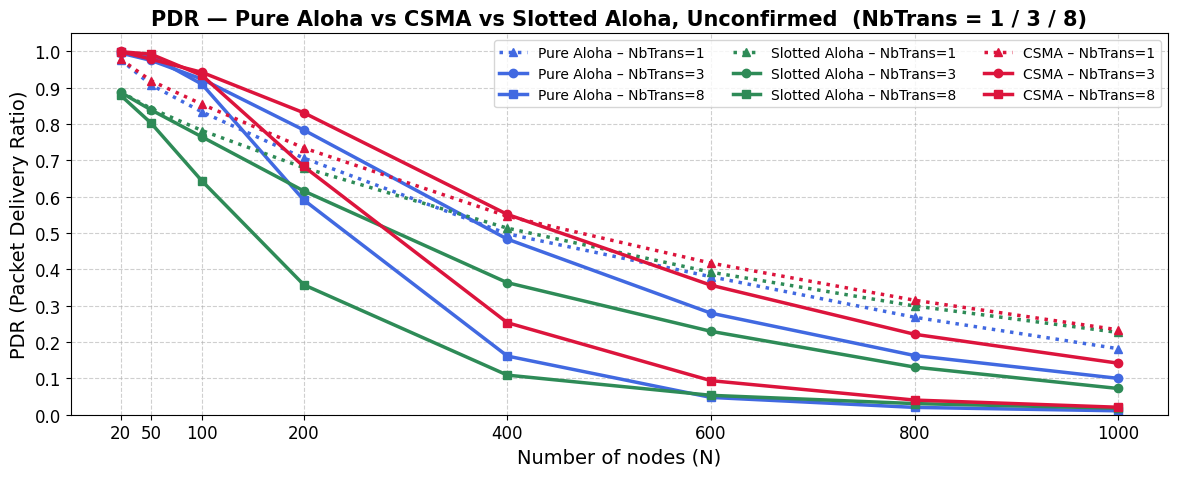

[OK] pdr_all_protocols_unc.pdf sauvegardé


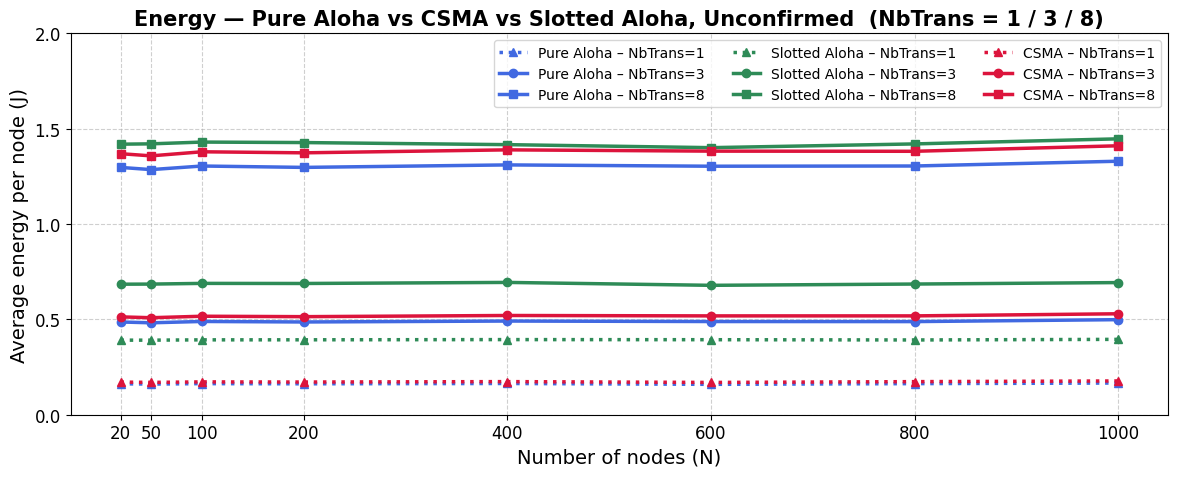

[OK] energy_all_protocols_unc.pdf sauvegardé


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import os

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 10,
})

BASE = os.getcwd()

# ── Chemins ────────────────────────────────────────────────────────────────────
PATHS = {
    "pure_aloha": {
        "0retx": os.path.join(BASE, "purealohaSansRetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "2retx": os.path.join(BASE, "pureAlohaAvec2RetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "7retx": os.path.join(BASE, "pureAlohaAvec7RetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
    },
    "slotted_aloha": {
        "0retx": os.path.join(BASE, "SlottedAlohaSansRetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "2retx": os.path.join(BASE, "SlottedAlohaAvec2RetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "7retx": os.path.join(BASE, "SlottedAlohaAvec7RetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
    },
    "csma": {
        "0retx": os.path.join(BASE, "CSMASansRetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "2retx": os.path.join(BASE, "CSMAAvec2RetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "7retx": os.path.join(BASE, "CSMAAvec7RetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
    },
}

custom_ticks = [20, 50, 100, 200, 400, 600, 800, 1000]

# ── Encodage visuel ────────────────────────────────────────────────────────────
COLORS = {
    "pure_aloha":    "royalblue",
    "slotted_aloha": "seagreen",
    "csma":          "crimson",
}

PROTO_LABELS = {
    "pure_aloha":    "Pure Aloha",
    "slotted_aloha": "Slotted Aloha",
    "csma":          "CSMA",
}

MARKERS    = {"0retx": "^", "2retx": "o", "7retx": "s"}
LINESTYLES = {"0retx": ":",  "2retx": "-",  "7retx": "-"}
NBTRANS_LABELS = {
    "0retx": "NbTrans=1",
    "2retx": "NbTrans=3",
    "7retx": "NbTrans=8",
}

# Génération du dictionnaire de style (9 courbes)
CURVES = {}
for proto in PATHS:
    for retx in ["0retx", "2retx", "7retx"]:
        key = f"{proto}_{retx}"
        CURVES[key] = dict(
            color=COLORS[proto],
            marker=MARKERS[retx],
            ls=LINESTYLES[retx],
            lw=2.5,
            ms=6,
            label=f"{PROTO_LABELS[proto]} – {NBTRANS_LABELS[retx]}",
        )


# ── Helpers ────────────────────────────────────────────────────────────────────
def _load(csv_path):
    df = pd.read_csv(csv_path)
    for col in ["name", "module", "run"]:
        df[col] = df[col].astype(str).str.strip()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    return df


def _N_dict(df):
    itervars = df[df["type"] == "itervar"]
    N_vals = itervars[itervars["attrname"] == "N"][["run", "attrvalue"]].copy()
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")
    return dict(zip(N_vals["run"], N_vals["N"]))


def get_results(csv_path, scalar_name, module_filter=None):
    df = _load(csv_path)
    N_vals = (df[df["type"] == "itervar"]
              .query("attrname == 'N'")[["run", "attrvalue"]].copy())
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")

    mask = df["name"] == scalar_name
    if module_filter:
        mask &= df["module"].str.contains(module_filter, na=False)
    sub = df[mask].copy()
    if sub.empty:
        print(f"[WARN] '{scalar_name}' absent dans {csv_path}")
        return pd.DataFrame(columns=["N", "value"])

    per_run = sub.groupby("run")["value"].mean()
    wide = per_run.reset_index().merge(N_vals[["run", "N"]], on="run")
    return wide.groupby("N", as_index=False)["value"].mean().sort_values("N")


def get_pdr_unconfirmed(csv_path):
    """PDR unconfirmed : LoRa_NS_DER depuis le networkServer (fallback sans filtre)."""
    der = get_results(csv_path, "LoRa_NS_DER", module_filter="networkServer")
    if der.empty:
        der = get_results(csv_path, "LoRa_NS_DER")
    return der


def get_energy_per_node(csv_path, with_csma_energy=False):
    """Energie moyenne par nœud actif (node_idx < N)."""
    df = _load(csv_path)
    N_dict_map = _N_dict(df)

    mask_e = (df["name"] == "totalEnergyConsumed") & \
              df["module"].str.contains("loRaNodes", na=False)
    sub_e = df[mask_e][["run", "module", "value"]].rename(columns={"value": "energy"})

    if sub_e.empty:
        mask_e2 = df["name"] == "totalEnergyConsumed"
        sub_e = df[mask_e2][["run", "module", "value"]].rename(columns={"value": "energy"})
        if sub_e.empty:
            print(f"[WARN] totalEnergyConsumed absent dans {csv_path}")
            return pd.DataFrame(columns=["N", "value"])

    if with_csma_energy:
        mask_c = (df["name"] == "Total CSMA Energy (J)") & \
                  df["module"].str.contains("loRaNodes", na=False)
        sub_c = df[mask_c][["run", "module", "value"]].rename(columns={"value": "csma_energy"})
        if sub_c.empty:
            print(f"[WARN] 'Total CSMA Energy' absent dans {csv_path} — non ajouté")
            sub_e["total"] = sub_e["energy"]
            merged = sub_e
        else:
            merged = sub_e.merge(sub_c, on=["run", "module"], how="left")
            merged["csma_energy"] = merged["csma_energy"].fillna(0)
            merged["total"] = merged["energy"] + merged["csma_energy"]
    else:
        sub_e["total"] = sub_e["energy"]
        merged = sub_e

    merged["node_idx"] = merged["module"].str.extract(r"loRaNodes\[(\d+)\]").astype(float)
    merged["N"] = merged["run"].map(N_dict_map)
    merged = merged.dropna(subset=["N", "node_idx"])
    merged = merged[merged["node_idx"] < merged["N"]]

    mean_per_run = merged.groupby(["run", "N"])["total"].mean().reset_index()
    result = mean_per_run.groupby("N", as_index=False)["total"].mean().sort_values("N")
    return result.rename(columns={"total": "value"})


# ── Chargement des données ─────────────────────────────────────────────────────
pdr    = {}
energy = {}

for proto, paths in PATHS.items():
    use_csma_energy = (proto == "csma")
    for retx, path in paths.items():
        key = f"{proto}_{retx}"
        pdr[key]    = get_pdr_unconfirmed(path)
        energy[key] = get_energy_per_node(path, with_csma_energy=use_csma_energy)


# ── Affichage tabulaire ────────────────────────────────────────────────────────
def print_scenario_tables(data_dict, title, unit=""):
    print(f"\n{'='*70}")
    print(f"  {title}")
    print(f"{'='*70}")
    for key, df in data_dict.items():
        label = CURVES[key]["label"]
        print(f"\n--- {label} ---")
        if df is None or df.empty:
            print("  Aucune donnée")
            continue
        display = df.copy()
        display["value"] = display["value"].round(6)
        if unit:
            display["value"] = display["value"].astype(str) + f" {unit}"
        print(display.to_string(index=False))

print_scenario_tables(pdr,    "PDR (LoRa_NS_DER) — Unconfirmed")
print_scenario_tables(energy, "Énergie moyenne par nœud — Unconfirmed", unit="J")


# ── Figure 1 : PDR ────────────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(12, 5))

for key, df in pdr.items():
    if df is not None and not df.empty:
        s = CURVES[key]
        ax1.plot(df["N"], df["value"],
                 marker=s["marker"], color=s["color"],
                 linewidth=s["lw"], markersize=s["ms"],
                 linestyle=s["ls"], label=s["label"])

ax1.set_xlabel("Number of nodes (N)")
ax1.set_ylabel("PDR (Packet Delivery Ratio)")
ax1.set_title(
    "PDR — Pure Aloha vs CSMA vs Slotted Aloha, Unconfirmed  (NbTrans = 1 / 3 / 8)",
    fontweight="bold"
)
ax1.set_ylim(0, 1.05)
ax1.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax1.set_xticks(custom_ticks)
ax1.legend(ncol=3)   # 1 colonne par protocole
ax1.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("pdr_all_protocols_unc.pdf", bbox_inches="tight")
plt.show()
print("[OK] pdr_all_protocols_unc.pdf sauvegardé")


# ── Figure 2 : Énergie ────────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(12, 5))

for key, df in energy.items():
    if df is not None and not df.empty:
        s = CURVES[key]
        ax2.plot(df["N"], df["value"],
                 marker=s["marker"], color=s["color"],
                 linewidth=s["lw"], markersize=s["ms"],
                 linestyle=s["ls"], label=s["label"])

ax2.set_xlabel("Number of nodes (N)")
ax2.set_ylabel("Average energy per node (J)")
ax2.set_title(
    "Energy — Pure Aloha vs CSMA vs Slotted Aloha, Unconfirmed  (NbTrans = 1 / 3 / 8)",
    fontweight="bold"
)
ax2.set_ylim(bottom=0, top=2)
ax2.yaxis.set_major_locator(plt.MultipleLocator(0.5))
ax2.set_xticks(custom_ticks)
ax2.legend(ncol=3)
ax2.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("energy_all_protocols_unc.pdf", bbox_inches="tight")
plt.show()
print("[OK] energy_all_protocols_unc.pdf sauvegardé")